# ERCOT Houston Hub — Exploratory Data Analysis

This notebook covers:
1. **Setup** — load processed data, define constants
2. **Target EDA** — distribution and time-series structure of RTM price volatility
3. **Feature EDA** — key predictors (net load, wind error, forecast uncertainty, ancillary prices)
4. **Regime analysis** — extreme events (Winter Storm Uri, summer peaks, autocorrelation)
5. **Modeling roadmap** — recommended models, features, and validation strategy
6. **Baseline models** — Ridge regression, XGBoost v1, spike classifier
7. **Advanced models** — XGBoost v2 (29 features), HAR-RV, GARCH, XGBoost v3 (29+GARCH = 30 features), rolling Lasso, post-Uri window test
8. **Error analysis** — MAE by hour/month, spike vs non-spike, PR-AUC, leaderboard
9. **Rolling forecast & drift detection** — fixed vs sliding-window model comparison; Page-Hinkley, KS, Jensen-Shannon drift tests

**Data range:** 2017-07-01 → 2025-12-31 (hourly, ~74,000 rows).  
**Train**: 2017-07 → 2024-12 · **Test**: 2025 · **Hold-out**: 2026 (do not load).

## 1. Setup

Load the pre-processed combined dataset (`ercot_combined.parquet`). This wide table aligns all 9 ERCOT datasets by delivery hour (`ts_utc`), enabling exploratory analysis of how market prices, load, wind, and ancillary services co-vary over time.

> **Note**: `ercot_combined` is for EDA only. Model features are built separately using `build_features()` with a leakage-safe 6PM D-1 cutoff (see Section 6).


In [1]:
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # not running in Jupyter

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

PROCESSED_ROOT = Path('data/processed/ercot')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
plt.rcParams['figure.max_open_warning'] = 50
sns.set_style('whitegrid')

# EDA exploration threshold — used only to count extreme spikes in EDA section 2
# The model's binary target uses spike_flag = (rtm_price_mean > 100)

print('Imports OK')


Imports OK


In [2]:
df = pd.read_parquet(PROCESSED_ROOT / 'ercot_combined.parquet')
df['ts_utc'] = pd.to_datetime(df['ts_utc'])
df = df.sort_values('ts_utc').reset_index(drop=True)

print(f'Rows: {len(df):,}  |  Columns: {len(df.columns)}')
print(f'Range: {df.ts_utc.min()} -> {df.ts_utc.max()}')
print(f'\nColumns:\n{list(df.columns)}')

Rows: 74,569  |  Columns: 64
Range: 2017-06-29 23:00:00 -> 2025-12-31 23:00:00

Columns:
['ts_utc', 'load_houston', 'load_total', 'wz_coast', 'wz_east', 'wz_far_west', 'wz_north', 'wz_north_c', 'wz_southern', 'wz_south_c', 'wz_west', 'wz_total', 'rtm_price_max_hb_busavg', 'rtm_price_max_hb_houston', 'rtm_price_mean_hb_busavg', 'rtm_price_mean_hb_houston', 'rtm_price_min_hb_busavg', 'rtm_price_min_hb_houston', 'rtm_price_std_hb_busavg', 'rtm_price_std_hb_houston', 'dam_price_houston', 'dam_price_avg', 'system_lambda', 'total_resource_mw', 'total_irr_mw', 're_share', 'houston_resource_mw', 'houston_irr_mw', 'houston_re_share', 'outf_horizon_h', 'outf_total_resource_mw', 'outf_total_irr_mw', 'outf_total_resource_mw_std_48h', 'outf_total_irr_mw_std_48h', 'mcpc_ecrs', 'mcpc_nspin', 'mcpc_regdn', 'mcpc_regup', 'mcpc_rrs', 'fc_horizon_h', 'fc_coast', 'fc_system_total', 'fc_coast_std_48h', 'fc_system_total_std_48h', 'wf_horizon_h', 'wf_stwpf_system_wide', 'wf_stwpf_lz_south_houston', 'wf_stwpf

## 2. Target Variable: RTM Price Volatility

**Modeling goal**: predict *how volatile* RTM prices will be for a given delivery hour — before that hour arrives. This enables energy traders and grid operators to anticipate uncertainty in real-time market prices.

**Primary target**: `rtm_price_std_hb_houston` — std dev of the 4 intra-hour 15-min RTM prices at Houston Hub.  
High std = price moved a lot within that hour = realized intra-hour volatility.  
The distribution is heavily right-skewed; we use `log1p` transform for regression.

**Secondary target**: `spike_flag` — binary indicator for hours where `rtm_price_mean > $100/MWh`.

### Why not use the DAM-RTM spread as the target?

A natural first instinct is to predict the DAM-RTM spread (`dam_price - rtm_price_mean`), since it measures how wrong the day-ahead forecast was. However:
- It conflates **level errors** (mean mispricing) with **volatility** (uncertainty about the mean)
- It can be negative even in highly volatile hours if the DAM overestimated prices
- RTM std dev directly measures the uncertainty that market participants face within a delivery hour

We use `rtm_price_std` (volatility) as the primary regression target and `spike_flag` for the binary task.


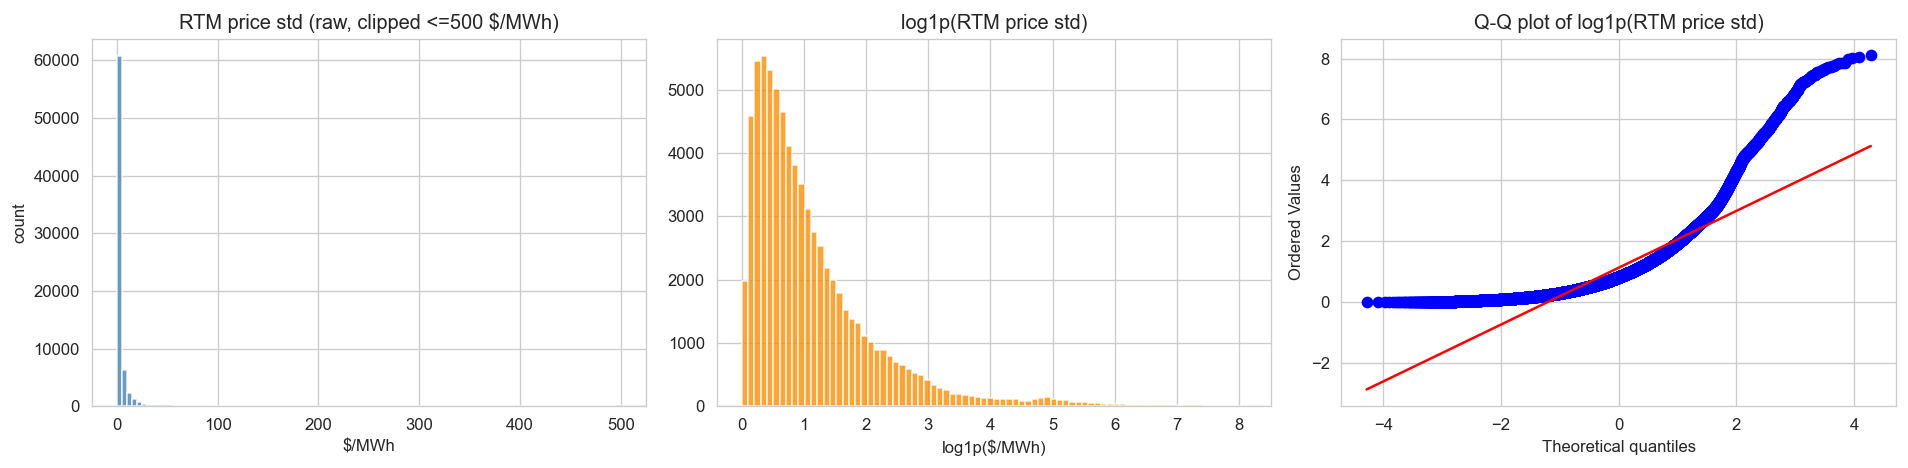

Raw:    mean=10.3  median=1.3  p95=21.6  p99=178.7  max=3320.0
Skewness (raw): 20.55  |  skewness (log1p): 2.10


In [3]:
# Distribution of RTM price std
_vol = df['rtm_price_std_hb_houston'].dropna()
_log_vol = np.log1p(_vol)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(_vol.clip(upper=500), bins=100, color='steelblue', alpha=0.8)
axes[0].set_title('RTM price std (raw, clipped <=500 $/MWh)')
axes[0].set_xlabel('$/MWh'); axes[0].set_ylabel('count')

axes[1].hist(_log_vol, bins=80, color='darkorange', alpha=0.8)
axes[1].set_title('log1p(RTM price std)')
axes[1].set_xlabel('log1p($/MWh)')

stats.probplot(_log_vol, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot of log1p(RTM price std)')

plt.tight_layout()
plt.show()

print(f'Raw:    mean={_vol.mean():.1f}  median={_vol.median():.1f}  '
      f'p95={_vol.quantile(.95):.1f}  p99={_vol.quantile(.99):.1f}  '
      f'max={_vol.max():.1f}')
print(f'Skewness (raw): {_vol.skew():.2f}  |  skewness (log1p): {_log_vol.skew():.2f}')

We examine RTM volatility through four complementary views: (1) distribution shape and log-transform justification, (2) full time series to show regime shifts, (3) diurnal and seasonal patterns, and (4) spike rate by hour and month.


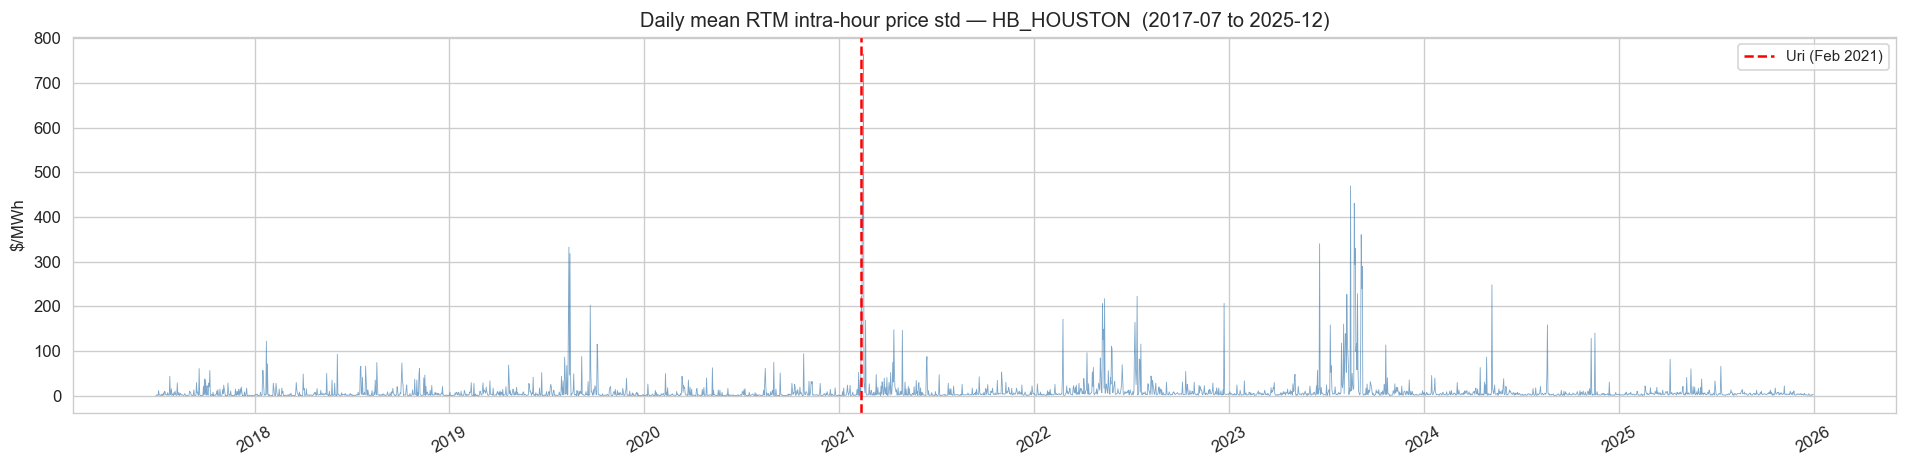

In [4]:
# Full time series of RTM volatility (daily mean)
_daily_vol = (
    df.set_index('ts_utc')['rtm_price_std_hb_houston']
      .resample('D').mean()
)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(_daily_vol.index, _daily_vol.values, lw=0.5, color='steelblue', alpha=0.7)
ax.axvline(pd.Timestamp('2021-02-10'), color='red', lw=1.5, linestyle='--', label='Uri (Feb 2021)')
ax.set_title('Daily mean RTM intra-hour price std — HB_HOUSTON  (2017-07 to 2025-12)')
ax.set_ylabel('$/MWh'); ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

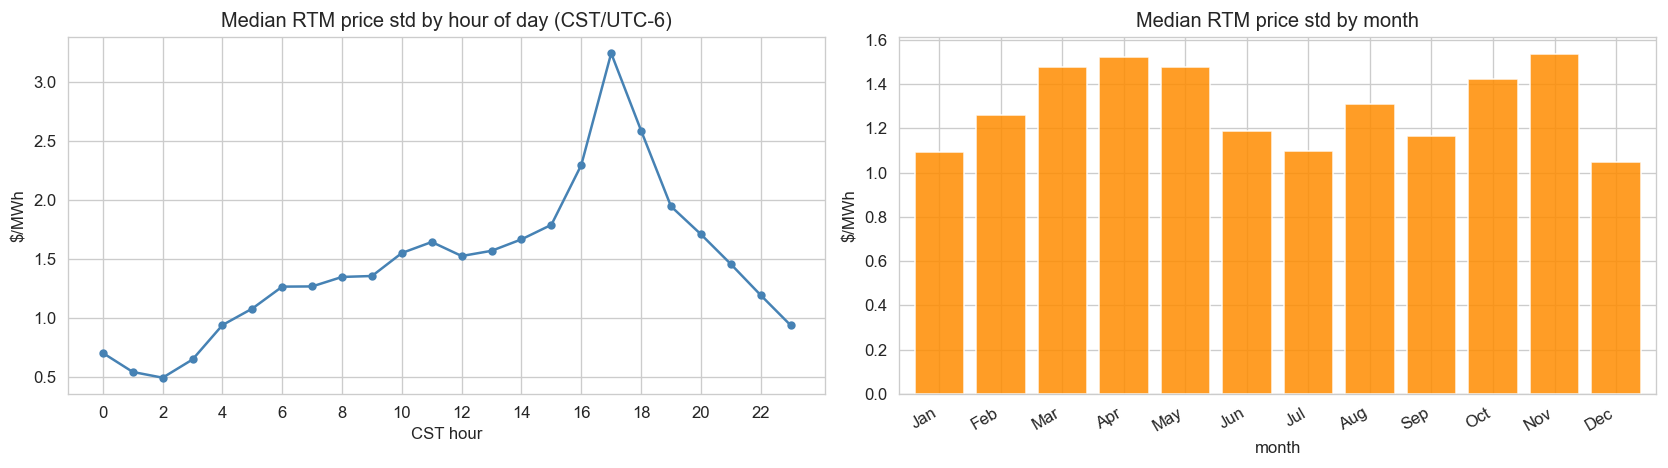

In [5]:
# Diurnal and seasonal volatility patterns
_months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby('hour')['rtm_price_std_hb_houston'].median().plot(
    ax=axes[0], marker='o', ms=4, lw=1.5, color='steelblue')
axes[0].set_title('Median RTM price std by hour of day (CST/UTC-6)')
axes[0].set_xlabel('CST hour'); axes[0].set_ylabel('$/MWh')
axes[0].set_xticks(range(0, 24, 2))

df.groupby('month')['rtm_price_std_hb_houston'].median().plot(
    kind='bar', ax=axes[1], color='darkorange', alpha=0.85, width=0.8)
axes[1].set_title('Median RTM price std by month')
axes[1].set_xticklabels(_months, rotation=30, ha='right')
axes[1].set_ylabel('$/MWh')

plt.tight_layout()
plt.show()

### 2.4 Spike Threshold Selection

To define the binary classification target `spike_flag`, we need to choose a threshold on `rtm_price_mean`.

**Candidate thresholds and their trade-offs:**

| Threshold | Spike rate | Issue |
|---|---|---|
| $50/MWh | ~10% | Too common — includes normal afternoon peaks; not "extreme" |
| **$100/MWh** | **~3%** | **✓ Chosen — rare enough to be genuinely extreme, common enough to learn from** |
| $200/MWh | ~1% | Too rare — fewer than 800 training examples; marginal improvement hard to measure |
| $500/MWh | ~0.1% | Only Uri-class events — nearly impossible to predict reliably |

**Why $100/MWh:**
1. Falls at approximately the 97th percentile of RTM prices — unambiguously extreme
2. Provides ~2,400 positive training hours (out of ~65,000) — sufficient for XGBoost to learn patterns
3. Captures both curtailment events ($100–$500) and extreme scarcity ($500+)
4. Operationally meaningful: $100/MWh is commonly used in energy markets as the "scarcity pricing" signal

The cell below computes spike rates across thresholds and plots the empirical CDF of RTM prices to visualize where each threshold falls.

Threshold exploration:
  RTM mean >    50 $/MWh:   9,243 hours  (12.40%)  ~p88
  RTM mean >   100 $/MWh:   2,334 hours  (3.13%)  ~p97
  RTM mean >   200 $/MWh:   1,037 hours  (1.39%)  ~p99
  RTM mean >   500 $/MWh:     516 hours  (0.69%)  ~p99
  RTM mean >  1000 $/MWh:     327 hours  (0.44%)  ~p100

p95  = $79/MWh
p97  = $103/MWh
p99  = $296/MWh
p999 = $8946/MWh

>> MODEL binary target: spike_flag = (rtm_price_mean > $100/MWh)  [chosen threshold]


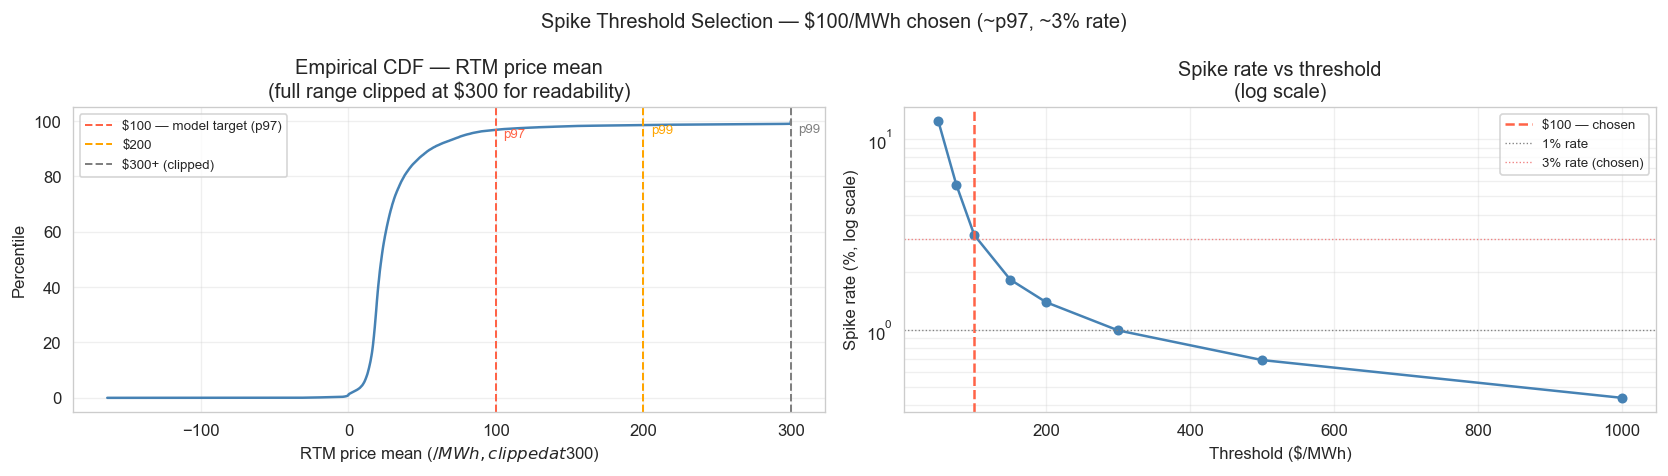


Uri-class extreme spikes (>$500/MWh, not the model target):
  -> 516 hours  (0.692%)


In [6]:
# Spike threshold selection — rates and CDF visualization
import numpy as np
import matplotlib.pyplot as plt

_rtm = df['rtm_price_mean_hb_houston'].dropna()

print("Threshold exploration:")
for thr in [50, 100, 200, 500, 1000]:
    n = (_rtm > thr).sum()
    pct = _rtm.quantile(1 - n / len(_rtm))
    print(f'  RTM mean > {thr:>5} $/MWh:  {n:>6,} hours  ({100*n/len(_rtm):.2f}%)  ~p{100*(1 - n/len(_rtm)):.0f}')

print(f'\np95  = ${_rtm.quantile(.95):.0f}/MWh')
print(f'p97  = ${_rtm.quantile(.97):.0f}/MWh')
print(f'p99  = ${_rtm.quantile(.99):.0f}/MWh')
print(f'p999 = ${_rtm.quantile(.999):.0f}/MWh')
print(f'\n>> MODEL binary target: spike_flag = (rtm_price_mean > $100/MWh)  [chosen threshold]')

# ── CDF plot (clipped at $300 for readability; log-scale inset for extremes) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: ECDF clipped at $300
_clip = _rtm.clip(upper=300)
_sorted = np.sort(_clip)
_ecdf   = np.arange(1, len(_sorted) + 1) / len(_sorted)

axes[0].plot(_sorted, _ecdf * 100, lw=1.5, color='steelblue')
for thr, color, label in [(100, 'tomato', '$100 — model target (p97)'),
                           (200, 'orange', '$200'),
                           (300, 'gray',   '$300+ (clipped)')]:
    axes[0].axvline(thr, color=color, lw=1.2, ls='--', label=label)
    pct_val = (_rtm <= thr).mean() * 100
    axes[0].annotate(f'p{pct_val:.0f}', xy=(thr, pct_val), xytext=(thr + 5, pct_val - 3),
                     fontsize=8, color=color)
axes[0].set_xlabel('RTM price mean ($/MWh, clipped at $300)')
axes[0].set_ylabel('Percentile')
axes[0].set_title('Empirical CDF — RTM price mean\n(full range clipped at $300 for readability)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: spike rate by threshold (log y-axis)
thresholds = [50, 75, 100, 150, 200, 300, 500, 1000]
rates = [100 * (_rtm > t).mean() for t in thresholds]
axes[1].plot(thresholds, rates, 'o-', color='steelblue', lw=1.5, ms=5)
axes[1].axvline(100, color='tomato', lw=1.5, ls='--', label='$100 — chosen')
axes[1].axhline(1.0, color='gray', lw=0.8, ls=':', label='1% rate')
axes[1].axhline(3.0, color='lightcoral', lw=0.8, ls=':', label='3% rate (chosen)')
axes[1].set_yscale('log')
axes[1].set_xlabel('Threshold ($/MWh)')
axes[1].set_ylabel('Spike rate (%, log scale)')
axes[1].set_title('Spike rate vs threshold\n(log scale)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, which='both')

plt.suptitle('Spike Threshold Selection — $100/MWh chosen (~p97, ~3% rate)', fontsize=12)
plt.tight_layout()
plt.savefig('spike_threshold_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# For reference: Uri-class extreme events (>$500/MWh) — NOT the model target
print(f'\nUri-class extreme spikes (>$500/MWh, not the model target):')
print(f'  -> {(_rtm > 500).sum():,} hours  ({100*(_rtm > 500).mean():.3f}%)')

## 3. Feature EDA

### 3.1 Net Load — Primary Driver of Price Volatility

`net_load = system_load − wind_generation`. High net load means thermal generators must ramp up, increasing marginal cost and price volatility. Low net load (high wind penetration) can cause negative prices or curtailment events.


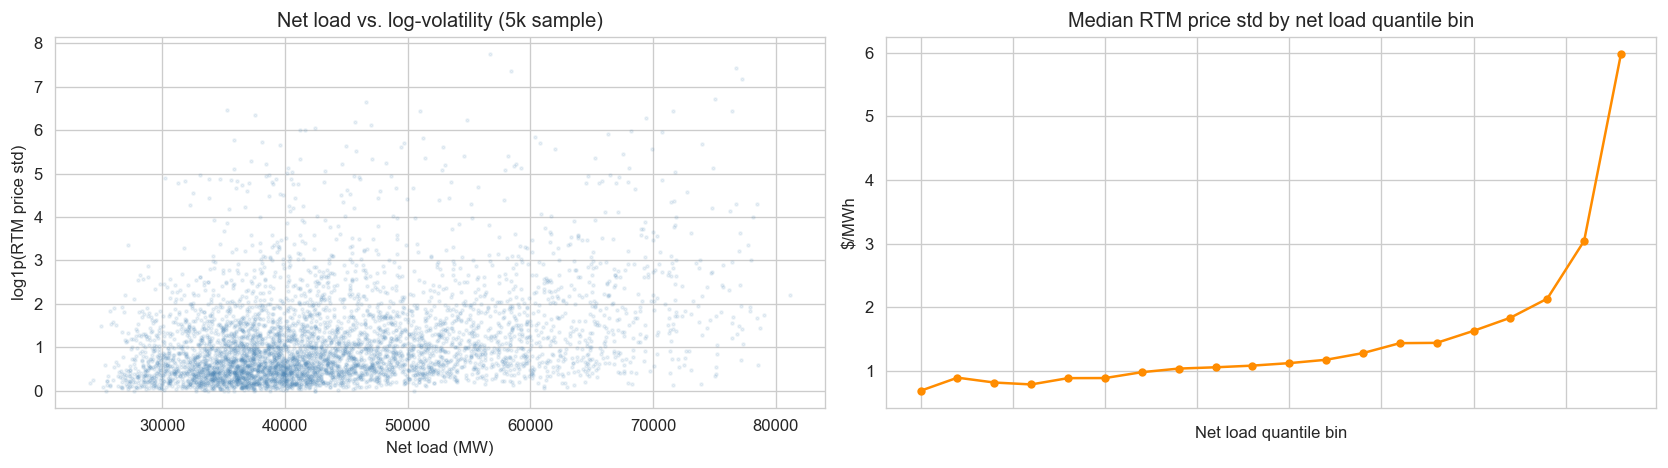

Correlation (net_load_mw vs log-vol): 0.322


In [7]:
# Net load vs. RTM volatility
_sub = df[['net_load_mw', 'rtm_price_std_hb_houston']].dropna()
_sub = _sub.copy()
_sub['nl_bin'] = pd.qcut(_sub['net_load_mw'], q=20)
_binned = _sub.groupby('nl_bin', observed=True)['rtm_price_std_hb_houston'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

idx = _sub.sample(min(5000, len(_sub)), random_state=42).index
axes[0].scatter(_sub.loc[idx, 'net_load_mw'],
                np.log1p(_sub.loc[idx, 'rtm_price_std_hb_houston']),
                alpha=0.1, s=3, color='steelblue')
axes[0].set_xlabel('Net load (MW)'); axes[0].set_ylabel('log1p(RTM price std)')
axes[0].set_title('Net load vs. log-volatility (5k sample)')

_binned.plot(ax=axes[1], marker='o', ms=4, lw=1.5, color='darkorange')
axes[1].set_title('Median RTM price std by net load quantile bin')
axes[1].set_xlabel('Net load quantile bin'); axes[1].set_ylabel('$/MWh')
axes[1].set_xticklabels([])

plt.tight_layout()
plt.show()

corr = np.corrcoef(_sub['net_load_mw'], np.log1p(_sub['rtm_price_std_hb_houston']))[0,1]
print(f'Correlation (net_load_mw vs log-vol): {corr:.3f}')

### 3.2 Wind Forecast Error — proximate cause of RTM spikes

`wind_error_houston = gen_lz_south_houston - stwpf_lz_south_houston`  
Negative = wind underperformed forecast -> real-time must dispatch expensive backup.  
The relationship is asymmetric: underperformance hurts more than overperformance helps.

/var/folders/vf/16_9fg814l76_gcv900gxyzc0000gn/T/ipykernel_49468/1770118340.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([_neg.clip(upper=200), _pos.clip(upper=200)],


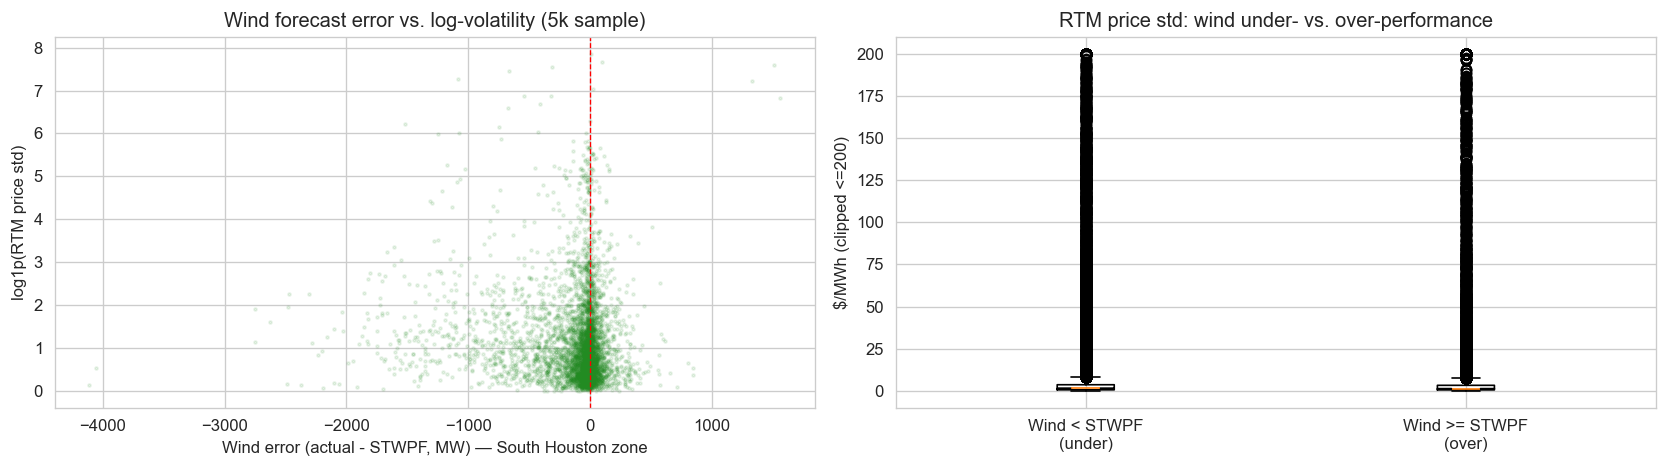

Median vol when wind < STWPF : 1.34 $/MWh  (n=50,179)
Median vol when wind >= STWPF: 1.20 $/MWh  (n=23,791)


In [8]:
# Wind error vs. RTM volatility
_sub2 = df[['wind_error_houston', 'rtm_price_std_hb_houston']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

idx2 = _sub2.sample(min(5000, len(_sub2)), random_state=42).index
axes[0].scatter(_sub2.loc[idx2, 'wind_error_houston'],
                np.log1p(_sub2.loc[idx2, 'rtm_price_std_hb_houston']),
                alpha=0.1, s=3, color='forestgreen')
axes[0].axvline(0, color='red', lw=0.8, linestyle='--')
axes[0].set_xlabel('Wind error (actual - STWPF, MW) — South Houston zone')
axes[0].set_ylabel('log1p(RTM price std)')
axes[0].set_title('Wind forecast error vs. log-volatility (5k sample)')

_neg = _sub2[_sub2['wind_error_houston'] < 0]['rtm_price_std_hb_houston']
_pos = _sub2[_sub2['wind_error_houston'] >= 0]['rtm_price_std_hb_houston']
axes[1].boxplot([_neg.clip(upper=200), _pos.clip(upper=200)],
                labels=['Wind < STWPF\n(under)', 'Wind >= STWPF\n(over)'],
                notch=True)
axes[1].set_title('RTM price std: wind under- vs. over-performance')
axes[1].set_ylabel('$/MWh (clipped <=200)')

plt.tight_layout()
plt.show()

print(f'Median vol when wind < STWPF : {_neg.median():.2f} $/MWh  (n={len(_neg):,})')
print(f'Median vol when wind >= STWPF: {_pos.median():.2f} $/MWh  (n={len(_pos):,})')

### 3.3 Forecast Revision Std — forward-looking uncertainty signal

`fc_coast_std_48h` / `wf_stwpf_lz_south_houston_std_48h` measure disagreement across
the D+1…D+7 forecast sequence.  High revision std = the market was uncertain about this
delivery hour days in advance — a genuine pre-delivery signal of volatility risk.

Both are Houston/Coast-specific: `fc_coast_std_48h` captures Coast zone load forecast
uncertainty; `wf_stwpf_lz_south_houston_std_48h` captures South Houston wind generation
forecast uncertainty.

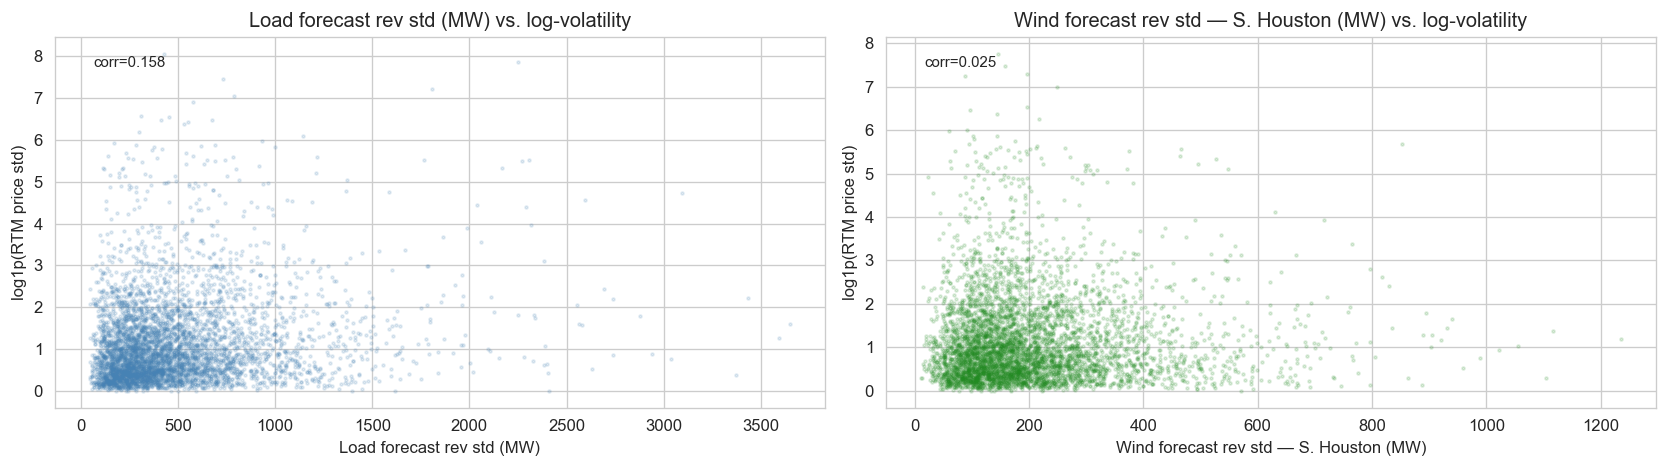

In [9]:
# Forecast revision std vs. RTM volatility
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, fcol, label, color in [
    (axes[0], 'fc_system_total_std_48h',      'Load forecast rev std (MW)',   'steelblue'),
    (axes[1], 'wf_stwpf_lz_south_houston_std_48h', 'Wind forecast rev std — S. Houston (MW)', 'forestgreen'),
]:
    if fcol not in df.columns:
        ax.text(0.3, 0.5, f'{fcol}\nnot found', transform=ax.transAxes)
        continue
    _s = df[[fcol, 'rtm_price_std_hb_houston']].dropna()
    idx = _s.sample(min(5000, len(_s)), random_state=42).index
    ax.scatter(_s.loc[idx, fcol],
               np.log1p(_s.loc[idx, 'rtm_price_std_hb_houston']),
               alpha=0.15, s=3, color=color)
    ax.set_xlabel(label)
    ax.set_ylabel('log1p(RTM price std)')
    ax.set_title(f'{label} vs. log-volatility')
    corr = np.corrcoef(_s[fcol], np.log1p(_s['rtm_price_std_hb_houston']))[0,1]
    ax.text(0.05, 0.92, f'corr={corr:.3f}', transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.show()

### 3.4 DAM Price & DAM-RTM Spread

The day-ahead price reflects the market's prior expectation of scarcity.
`dam_rtm_spread = dam_price - rtm_mean`: negative when real-time was tighter than expected.
For D+1 forecasting, use the **previous day's** DAM price (known before delivery).

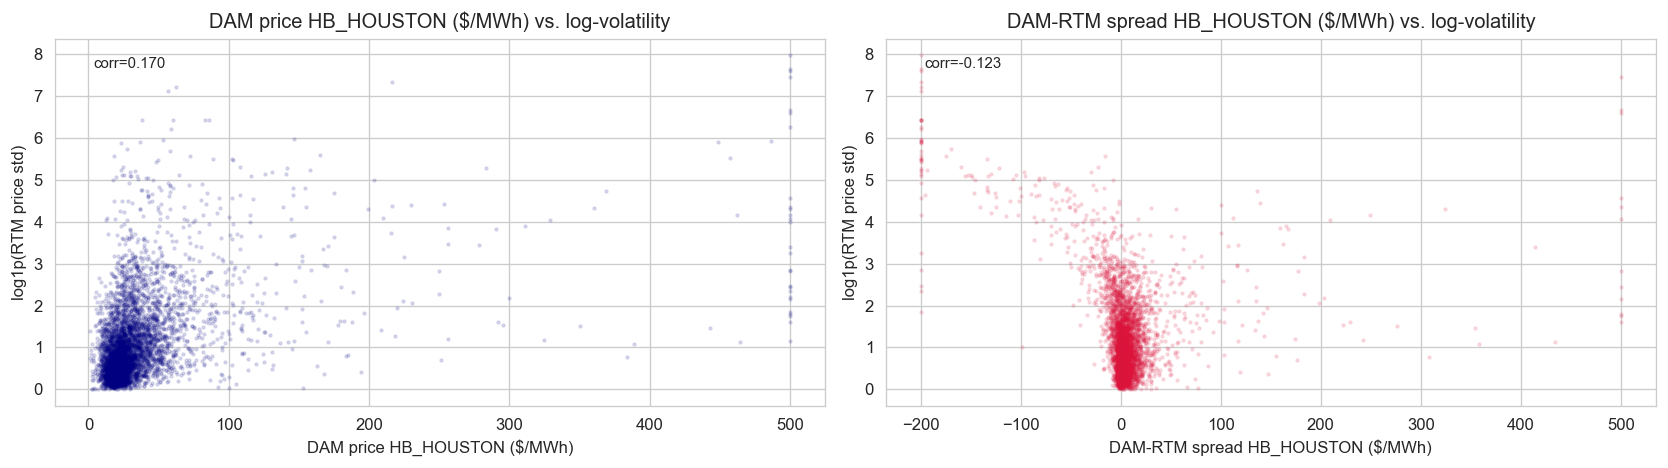

In [10]:
# DAM price and spread vs. RTM volatility
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, label, color in [
    (axes[0], 'dam_price_houston',      'DAM price HB_HOUSTON ($/MWh)',      'navy'),
    (axes[1], 'dam_rtm_spread_houston', 'DAM-RTM spread HB_HOUSTON ($/MWh)', 'crimson'),
]:
    if col not in df.columns:
        ax.text(0.3, 0.5, f'{col}\nnot found', transform=ax.transAxes)
        continue
    _s = df[[col, 'rtm_price_std_hb_houston']].dropna()
    _clip = _s[col].clip(-200, 500)
    idx = _s.sample(min(5000, len(_s)), random_state=42).index
    ax.scatter(_clip.loc[idx],
               np.log1p(_s.loc[idx, 'rtm_price_std_hb_houston']),
               alpha=0.12, s=3, color=color)
    ax.set_xlabel(label)
    ax.set_ylabel('log1p(RTM price std)')
    ax.set_title(f'{label} vs. log-volatility')
    corr = np.corrcoef(_s[col], np.log1p(_s['rtm_price_std_hb_houston']))[0,1]
    ax.text(0.05, 0.92, f'corr={corr:.3f}', transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.show()

### 3.5 Ancillary Service Prices — leading indicators of reserve tightness

When REGUP and RRS prices spike in the DAM, the system operator expected a tight reserve margin
the next day — a leading indicator of RTM volatility.

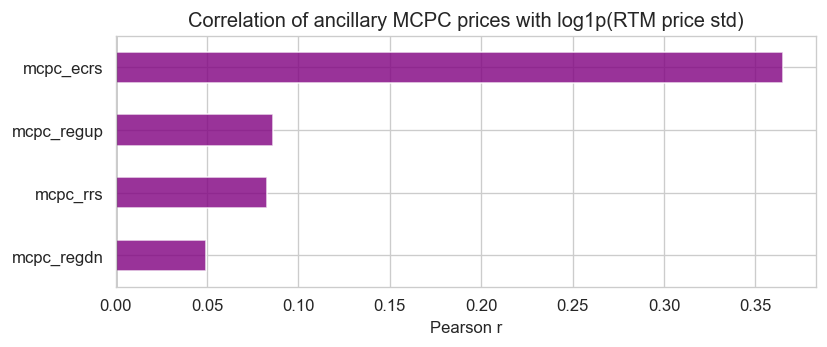

In [11]:
# Ancillary prices vs. RTM volatility
_anc_cols = [c for c in ['mcpc_rrs','mcpc_regup','mcpc_ecrs','mcpc_regdn','mcpc_nsrs']
             if c in df.columns]

corrs = {}
for c in _anc_cols:
    _s = df[[c, 'rtm_price_std_hb_houston']].dropna()
    corrs[c] = np.corrcoef(_s[c], np.log1p(_s['rtm_price_std_hb_houston']))[0,1]

fig, ax = plt.subplots(figsize=(7, 3))
pd.Series(corrs).sort_values().plot(kind='barh', ax=ax, color='purple', alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Correlation of ancillary MCPC prices with log1p(RTM price std)')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

### 3.6 Feature Candidates & Non-Linear Effects

Summary of all leakage-safe features available at the 6PM D-1 prediction cutoff, with their linear correlation to `log_rtm_std`.

| Feature | Source | Signal direction |
|---|---|---|
| `mcpc_regup`, `mcpc_rrs` | NP4-188 ancillary clearing | Positive — reserve scarcity → volatility |
| `dam_price_houston` | NP4-190 DAM | Positive — high DAM → tight supply |
| `fc_coast_std_48h` | NP3-565 forecast revision | Positive — uncertain forecast → uncertain delivery |
| `total_resource_mw` | NP3-233 outage | Positive — more outages → tighter margin |
| `wf_stwpf_lz_south_houston` | NP4-732 wind forecast (Houston zone) | Negative — more wind → lower net load |
| `temp_f_houston_avg` | Weather | Positive in summer — heat drives AC load → scarcity |

Pearson correlations only capture linear relationships. The following cells test whether key interactions (wind error × load, ECRS threshold effects) add non-linear predictive signal beyond the linear correlations.

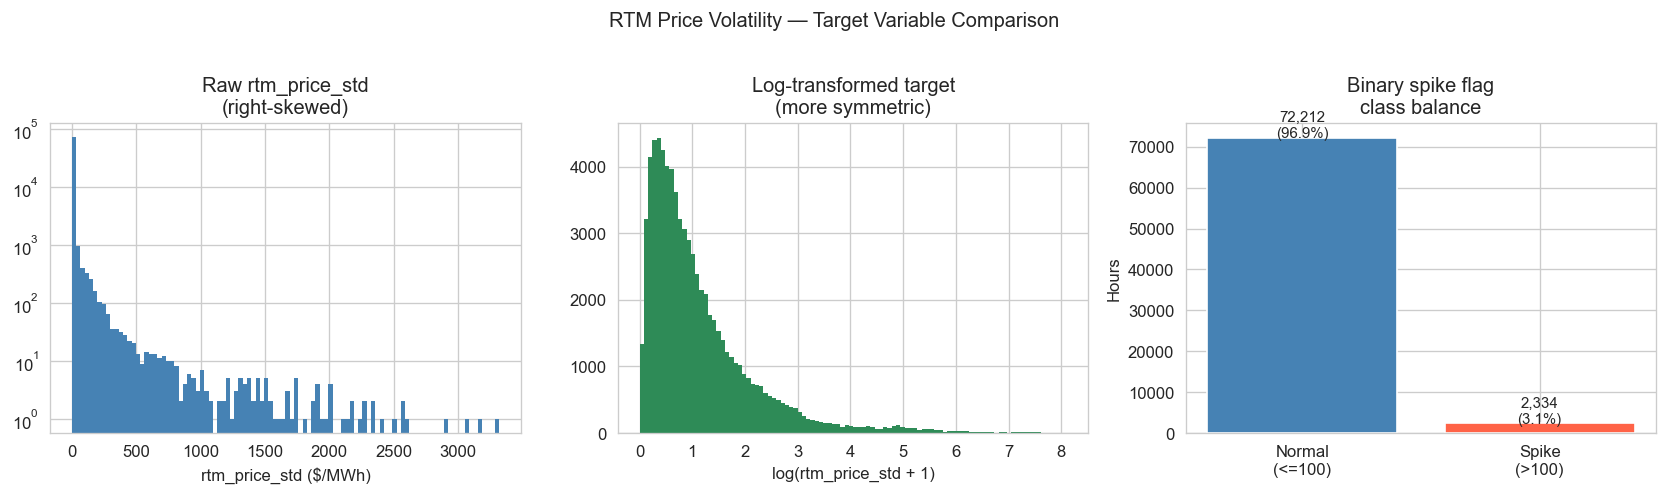

rtm_price_std stats:
count    74546.00
mean        10.33
std         74.49
min          0.00
25%          0.53
50%          1.29
75%          3.43
max       3319.99
Name: rtm_price_std, dtype: float64

log(rtm_price_std+1) stats:
count    74546.000
mean         1.134
std          1.040
min          0.000
25%          0.426
50%          0.828
75%          1.489
max          8.108
Name: rtm_price_std, dtype: float64

Spike rate: 3.13% of hours


In [12]:
# --- Target variable distribution analysis ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

_PROC = Path('data/processed/ercot')
rtm = pd.read_parquet(_PROC / 'np6_905_rtm_hourly_houston.parquet')[['ts_utc', 'rtm_price_std', 'rtm_price_mean']]
rtm = rtm.dropna(subset=['rtm_price_std'])

log_std = np.log1p(rtm['rtm_price_std'])
spike_flag = (rtm['rtm_price_mean'] > 100).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Raw rtm_price_std distribution
axes[0].hist(rtm['rtm_price_std'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('rtm_price_std ($/MWh)')
axes[0].set_title('Raw rtm_price_std\n(right-skewed)')
axes[0].set_yscale('log')

# 2. Log-transformed distribution
axes[1].hist(log_std, bins=100, color='seagreen', edgecolor='none')
axes[1].set_xlabel('log(rtm_price_std + 1)')
axes[1].set_title('Log-transformed target\n(more symmetric)')

# 3. Spike flag class balance
spike_counts = spike_flag.value_counts().sort_index()
axes[2].bar(['Normal\n(<=100)', 'Spike\n(>100)'], spike_counts.values, color=['steelblue', 'tomato'])
axes[2].set_title('Binary spike flag\nclass balance')
axes[2].set_ylabel('Hours')
for i, v in enumerate(spike_counts.values):
    axes[2].text(i, v + 50, f'{v:,}\n({v/len(rtm)*100:.1f}%)', ha='center', fontsize=9)

plt.suptitle('RTM Price Volatility — Target Variable Comparison', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f"rtm_price_std stats:")
print(rtm['rtm_price_std'].describe().round(2))
print(f"\nlog(rtm_price_std+1) stats:")
print(log_std.describe().round(3))
print(f"\nSpike rate: {spike_flag.mean()*100:.2f}% of hours")

Pearson correlation with log(rtm_price_std+1):
mcpc_ecrs                 0.365
fc_system_total           0.337
dam_price_houston         0.170
system_lambda             0.166
rtm_mean_lag24            0.109
mcpc_nspin                0.107
wgrpp_lz_south_houston    0.092
mcpc_regup                0.086
mcpc_rrs                  0.083
wind_error_houston       -0.083
total_resource_mw         0.067
mcpc_regdn                0.050


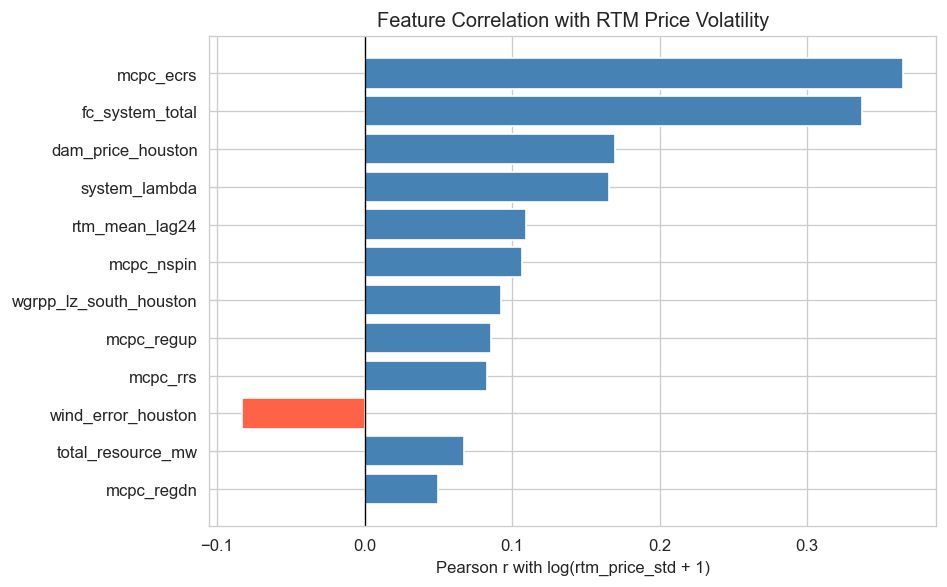

Plot saved.


In [13]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

_PROC = Path('data/processed/ercot')

# Load target
rtm = pd.read_parquet(_PROC / 'np6_905_rtm_hourly_houston.parquet')[['ts_utc', 'rtm_price_std', 'rtm_price_mean']]
rtm['log_rtm_std'] = np.log1p(rtm['rtm_price_std'])

# Load features
anc_regup = pd.read_parquet(_PROC / 'np4_188_mcpc_regup.parquet')[['ts_utc', 'mcpc_regup']]
anc_rrs   = pd.read_parquet(_PROC / 'np4_188_mcpc_rrs.parquet')[['ts_utc', 'mcpc_rrs']]
anc_ecrs  = pd.read_parquet(_PROC / 'np4_188_mcpc_ecrs.parquet')[['ts_utc', 'mcpc_ecrs']]
anc_nspin = pd.read_parquet(_PROC / 'np4_188_mcpc_nspin.parquet')[['ts_utc', 'mcpc_nspin']]
anc_regdn = pd.read_parquet(_PROC / 'np4_188_mcpc_regdn.parquet')[['ts_utc', 'mcpc_regdn']]
dam  = pd.read_parquet(_PROC / 'np4_190_dam_houston.parquet')[['ts_utc', 'dam_price_houston']]
lam  = pd.read_parquet(_PROC / 'np4_523_system_lambda.parquet')[['ts_utc', 'system_lambda']]
wind = pd.read_parquet(_PROC / 'np4_732_wind_houston.parquet')[['ts_utc', 'wind_error_houston', 'wgrpp_lz_south_houston']]
out  = pd.read_parquet(_PROC / 'np3_233_outage_total.parquet')[['ts_utc', 'total_resource_mw']]
fc   = pd.read_parquet(_PROC / 'np3_565_forecast1.parquet')[['ts_utc', 'fc_system_total']]

df_corr = rtm.copy()
for d in [anc_regup, anc_rrs, anc_ecrs, anc_nspin, anc_regdn, dam, lam, wind, out, fc]:
    df_corr = df_corr.merge(d, on='ts_utc', how='left')

df_corr = df_corr.sort_values('ts_utc').reset_index(drop=True)
df_corr['rtm_mean_lag24'] = df_corr['rtm_price_mean'].shift(24)

feat_cols = ['mcpc_regup', 'mcpc_rrs', 'mcpc_ecrs', 'mcpc_nspin', 'mcpc_regdn',
             'dam_price_houston', 'system_lambda', 'wind_error_houston',
             'wgrpp_lz_south_houston', 'total_resource_mw', 'fc_system_total', 'rtm_mean_lag24']

corr = df_corr[feat_cols + ['log_rtm_std']].corr()['log_rtm_std'].drop('log_rtm_std').sort_values(key=abs, ascending=False)
print("Pearson correlation with log(rtm_price_std+1):")
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if v > 0 else 'tomato' for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with log(rtm_price_std + 1)')
ax.set_title('Feature Correlation with RTM Price Volatility')
plt.tight_layout()
plt.savefig('data/processed/ercot/volatility_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

### Non-Linear Effects: Wind Error × Load Interaction

Pearson correlations only capture linear relationships. Key non-linear hypotheses:

1. **Wind error only matters when load is high** — a 1 GW wind miss is benign at low demand but catastrophic near peak
2. **ECRS price has a threshold effect** — volatility jumps sharply once ECRS crosses a scarcity price level
3. **DAM price × outage interaction** — high outages amplify the effect of high DAM prices

We test these by:
- Binning `fc_system_total` into load quartiles and computing correlation of `wind_error_houston` with `log_rtm_std` within each bin
- Scatter plots of key interactions with `log_rtm_std` as color/size
- Correlation of interaction terms (e.g. `wind_error_houston × fc_system_total`) vs individual features

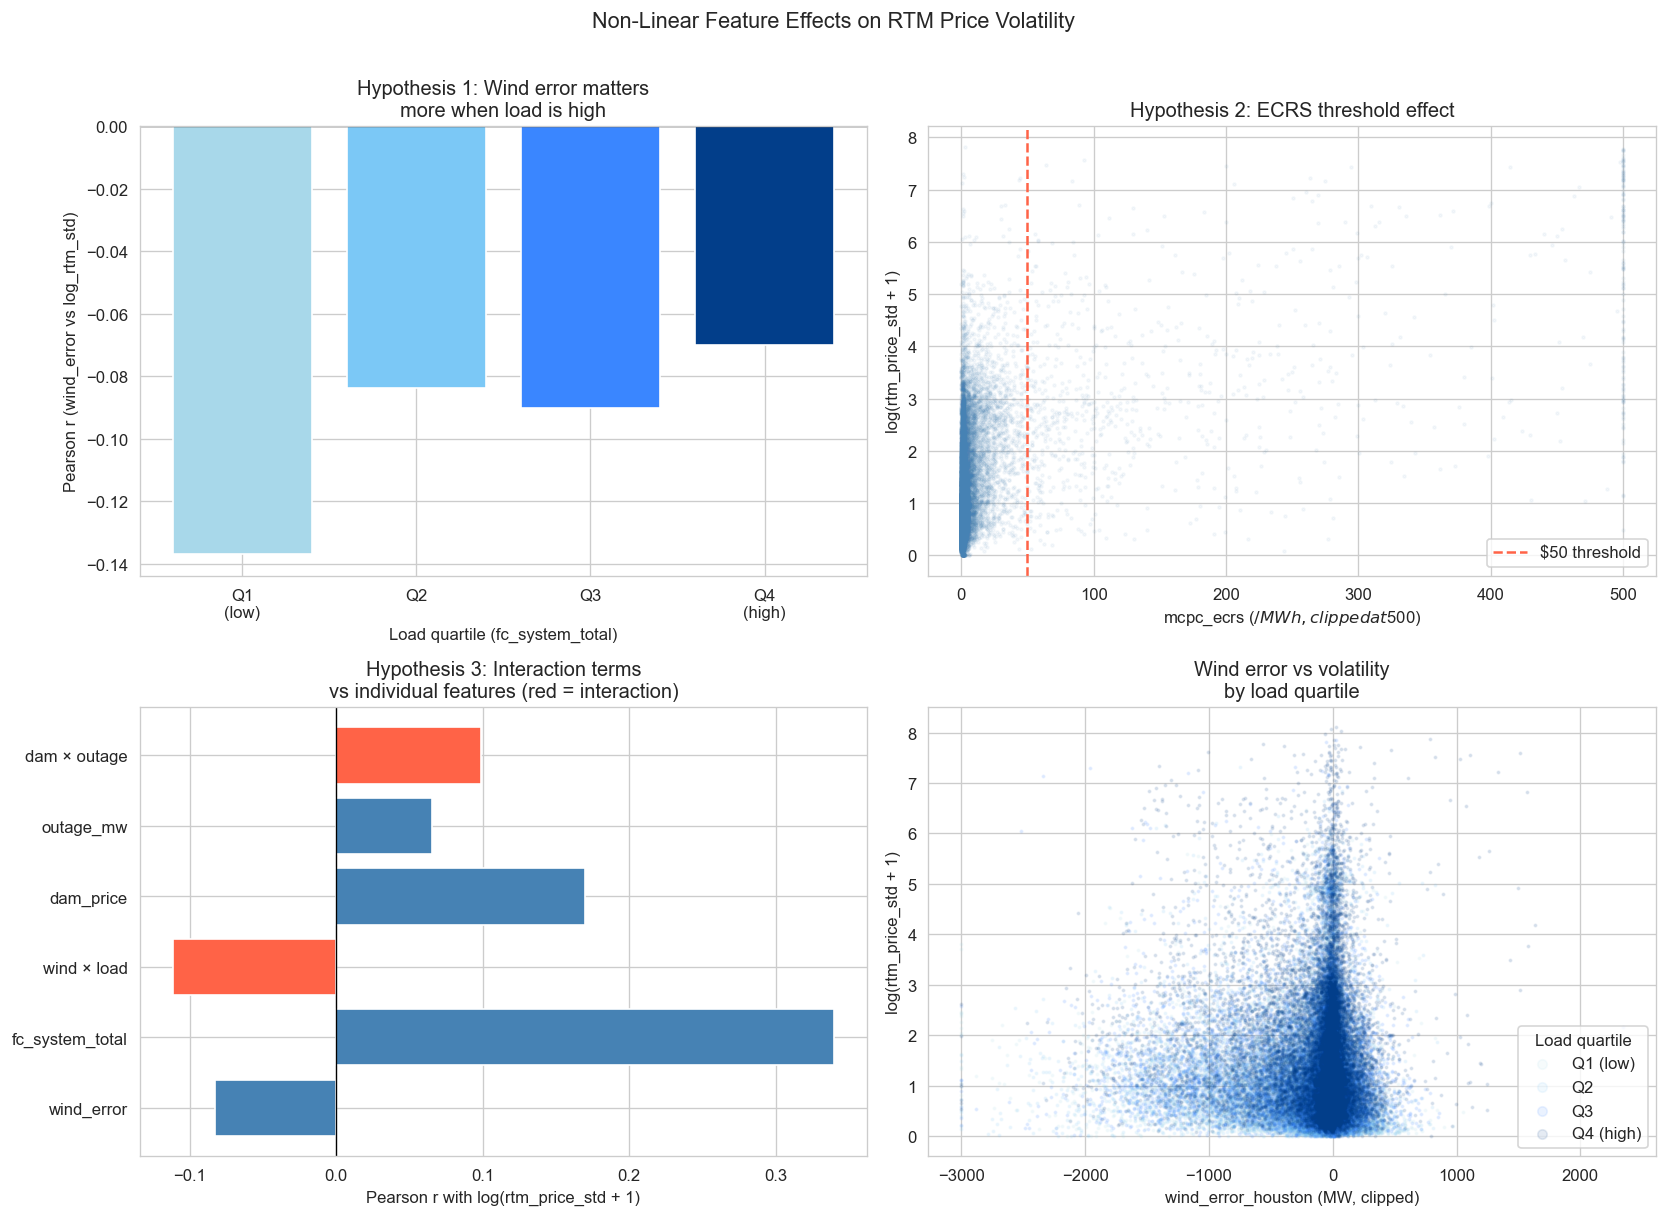

Plot saved.

Interaction term correlations with log(rtm_price_std+1):
  wind_error             r = -0.083
  fc_system_total        r = 0.340
  wind × load            r = -0.112
  dam_price              r = 0.170
  outage_mw              r = 0.066
  dam × outage           r = 0.099

Wind error correlation by load quartile:
load_quartile
Q1\n(low)    -0.137
Q2           -0.084
Q3           -0.090
Q4\n(high)   -0.070


In [14]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

_PROC = Path('data/processed/ercot')

# Load data
rtm  = pd.read_parquet(_PROC / 'np6_905_rtm_hourly_houston.parquet')[['ts_utc', 'rtm_price_std', 'rtm_price_mean']]
wind = pd.read_parquet(_PROC / 'np4_732_wind_houston.parquet')[['ts_utc', 'wind_error_houston', 'wgrpp_lz_south_houston']]
fc   = pd.read_parquet(_PROC / 'np3_565_forecast1.parquet')[['ts_utc', 'fc_system_total']]
out  = pd.read_parquet(_PROC / 'np3_233_outage_total.parquet')[['ts_utc', 'total_resource_mw']]
dam  = pd.read_parquet(_PROC / 'np4_190_dam_houston.parquet')[['ts_utc', 'dam_price_houston']]
ecrs = pd.read_parquet(_PROC / 'np4_188_mcpc_ecrs.parquet')[['ts_utc', 'mcpc_ecrs']]

df_nl = rtm.copy()
for d in [wind, fc, out, dam, ecrs]:
    df_nl = df_nl.merge(d, on='ts_utc', how='left')

df_nl['log_rtm_std'] = np.log1p(df_nl['rtm_price_std'])
df_nl = df_nl.dropna(subset=['log_rtm_std', 'fc_system_total', 'wind_error_houston'])

# Interaction terms
df_nl['wind_x_load'] = df_nl['wind_error_houston'] * df_nl['fc_system_total']
df_nl['dam_x_outage'] = df_nl['dam_price_houston'] * df_nl['total_resource_mw']
df_nl['load_quartile'] = pd.qcut(df_nl['fc_system_total'], q=4, labels=['Q1\n(low)', 'Q2', 'Q3', 'Q4\n(high)'])

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Wind error correlation with log_rtm_std by load quartile
quartile_corrs = df_nl.groupby('load_quartile', observed=True).apply(
    lambda g: g['wind_error_houston'].corr(g['log_rtm_std'])
)
axes[0, 0].bar(quartile_corrs.index, quartile_corrs.values, color=['#a8d8ea', '#7bc8f6', '#3a86ff', '#023e8a'])
axes[0, 0].axhline(0, color='black', linewidth=0.8)
axes[0, 0].set_xlabel('Load quartile (fc_system_total)')
axes[0, 0].set_ylabel('Pearson r (wind_error vs log_rtm_std)')
axes[0, 0].set_title('Hypothesis 1: Wind error matters\nmore when load is high')

# 2. ECRS threshold effect — scatter with threshold line
ecrs_data = df_nl.dropna(subset=['mcpc_ecrs'])
axes[0, 1].scatter(ecrs_data['mcpc_ecrs'].clip(upper=500), ecrs_data['log_rtm_std'],
                   alpha=0.05, s=3, color='steelblue')
axes[0, 1].axvline(50, color='tomato', linewidth=1.5, linestyle='--', label='$50 threshold')
axes[0, 1].set_xlabel('mcpc_ecrs ($/MWh, clipped at $500)')
axes[0, 1].set_ylabel('log(rtm_price_std + 1)')
axes[0, 1].set_title('Hypothesis 2: ECRS threshold effect')
axes[0, 1].legend()

# 3. Interaction term correlations vs individual
base_corrs = {
    'wind_error': df_nl['wind_error_houston'].corr(df_nl['log_rtm_std']),
    'fc_system_total': df_nl['fc_system_total'].corr(df_nl['log_rtm_std']),
    'wind × load': df_nl['wind_x_load'].corr(df_nl['log_rtm_std']),
    'dam_price': df_nl['dam_price_houston'].corr(df_nl['log_rtm_std']),
    'outage_mw': df_nl['total_resource_mw'].corr(df_nl['log_rtm_std']),
    'dam × outage': df_nl['dam_x_outage'].corr(df_nl['log_rtm_std']),
}
colors = ['tomato' if '×' in k else 'steelblue' for k in base_corrs]
axes[1, 0].barh(list(base_corrs.keys()), list(base_corrs.values()), color=colors)
axes[1, 0].axvline(0, color='black', linewidth=0.8)
axes[1, 0].set_xlabel('Pearson r with log(rtm_price_std + 1)')
axes[1, 0].set_title('Hypothesis 3: Interaction terms\nvs individual features (red = interaction)')

# 4. Wind error vs log_rtm_std colored by load quartile
for q, color in zip(['Q1\n(low)', 'Q2', 'Q3', 'Q4\n(high)'], ['#a8d8ea', '#7bc8f6', '#3a86ff', '#023e8a']):
    mask = df_nl['load_quartile'] == q
    axes[1, 1].scatter(df_nl.loc[mask, 'wind_error_houston'].clip(-3000, 3000),
                       df_nl.loc[mask, 'log_rtm_std'],
                       alpha=0.1, s=2, color=color, label=q.replace('\n', ' '))
axes[1, 1].set_xlabel('wind_error_houston (MW, clipped)')
axes[1, 1].set_ylabel('log(rtm_price_std + 1)')
axes[1, 1].set_title('Wind error vs volatility\nby load quartile')
axes[1, 1].legend(title='Load quartile', markerscale=4)

plt.suptitle('Non-Linear Feature Effects on RTM Price Volatility', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('data/processed/ercot/volatility_nonlinear_effects.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

# Print interaction term correlations
print("\nInteraction term correlations with log(rtm_price_std+1):")
for k, v in base_corrs.items():
    print(f"  {k:<22} r = {v:.3f}")

print("\nWind error correlation by load quartile:")
print(quartile_corrs.round(3).to_string())

### Non-Linear Effects — Conclusions

**Hypothesis 1 — Wind error × load**: NOT confirmed. Wind error is weakly negative at low load (r=−0.13) but near zero at peak. No load-quartile amplification. Drop `wind × load` interaction.

**Hypothesis 2 — ECRS threshold**: CONFIRMED in EDA — volatility fans out sharply above ~$50 ECRS. However, ECRS was **excluded from all models** because it only began in 2021-06, providing insufficient history for pre-Uri training windows.

**Hypothesis 3 — DAM × outage interaction**: NOT confirmed. Interaction term (r=0.094) weaker than DAM alone (r=0.165). Drop.

---

### Final Feature Set for Modeling

| Feature | Transform | Source |
|---|---|---|
| `fc_system_total` | as-is | np3_565 |
| `dam_price_houston` | as-is | np4_190 |
| `system_lambda` | as-is | np4_523 |
| `mcpc_regup`, `mcpc_rrs`, `mcpc_nspin` | as-is | np4_188 |
| `total_resource_mw` (outages) | as-is | np3_233 |
| `rtm_std_lag48` | as-is | np6_905 |
| `wgrpp_lz_south_houston` | as-is | np4_732 |
| `wind_error_houston` | tentative — weak signal | np4_732 |
| `temp_f_houston_avg`, `humidity_pct_houston_avg`, `wind_gust_mph_houston_avg`, `precip_in_houston_avg` | as-is (hourly avg) | weather_hourly |

**Target**: `log(rtm_price_std + 1)` (regression) · `rtm_price_mean > $100/MWh` (binary, secondary)

**Train window**: 2017-07 → 2024-12 · **Test**: 2025 · **Hold-out**: 2026

### 3.7 Weather: Houston vs Texas-Wide Correlation

We have two weather aggregates for each variable:
- **Houston avg** — stations in the Houston metro area (directly relevant to Houston Hub)
- **Texas avg** — stations statewide (captures West Texas wind/load, DFW demand, etc.)

Before using both in the model, we check whether they are redundant (high correlation → keep only Houston) or complementary (low correlation → both add signal).

Thresholds used:
- **r > 0.95**: highly redundant → drop Texas, keep Houston
- **0.80 < r ≤ 0.95**: strongly correlated but with regional divergence → evaluate by variable
- **r ≤ 0.80**: genuinely complementary → keep both

Variable                 r(Houston, Texas)  Decision
──────────────────────────────────────────────────────────────
Temperature (°F)                    0.9636  Houston only (redundant)
Humidity (%)                        0.8337  Keep both (regional signal)
Precipitation (in)                  0.6624  Keep both (complementary)
Wind Gust (mph)                     0.8063  Keep both (regional signal)
Pressure (hPa)                      0.9387  Keep both (regional signal)


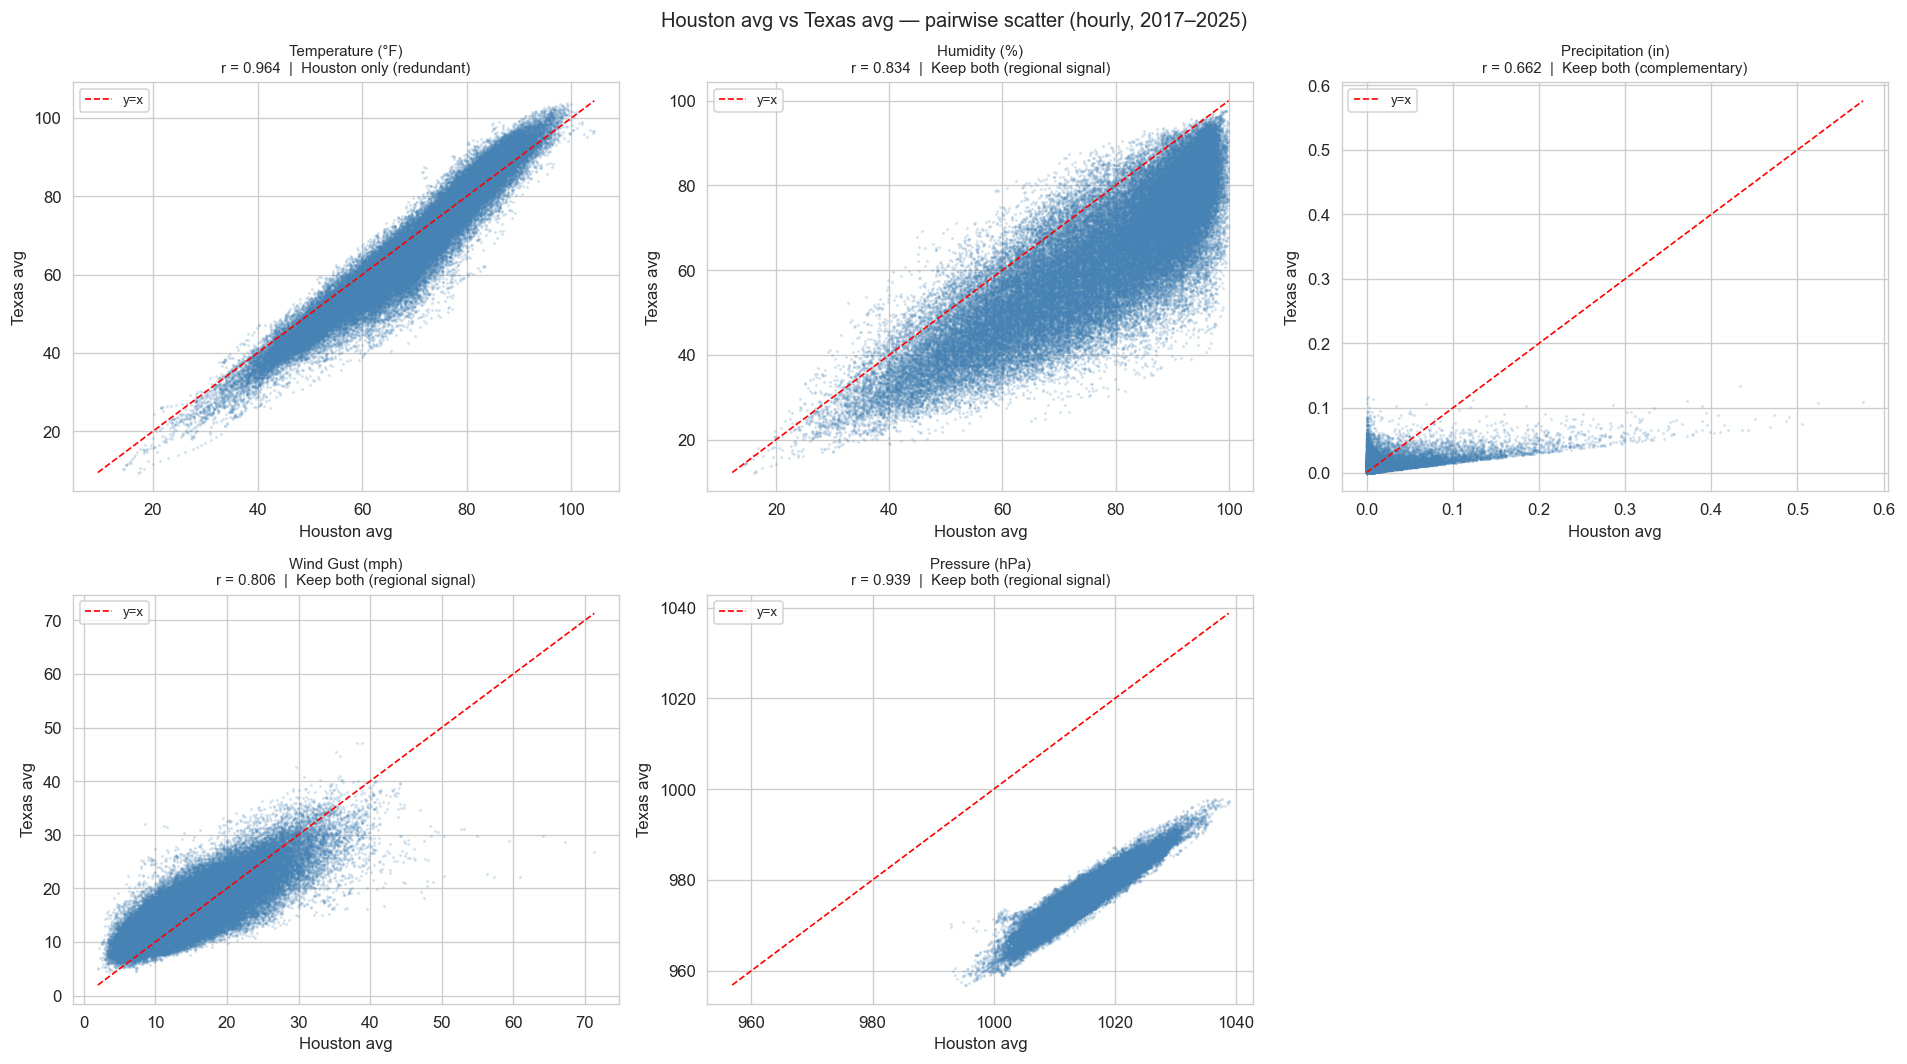

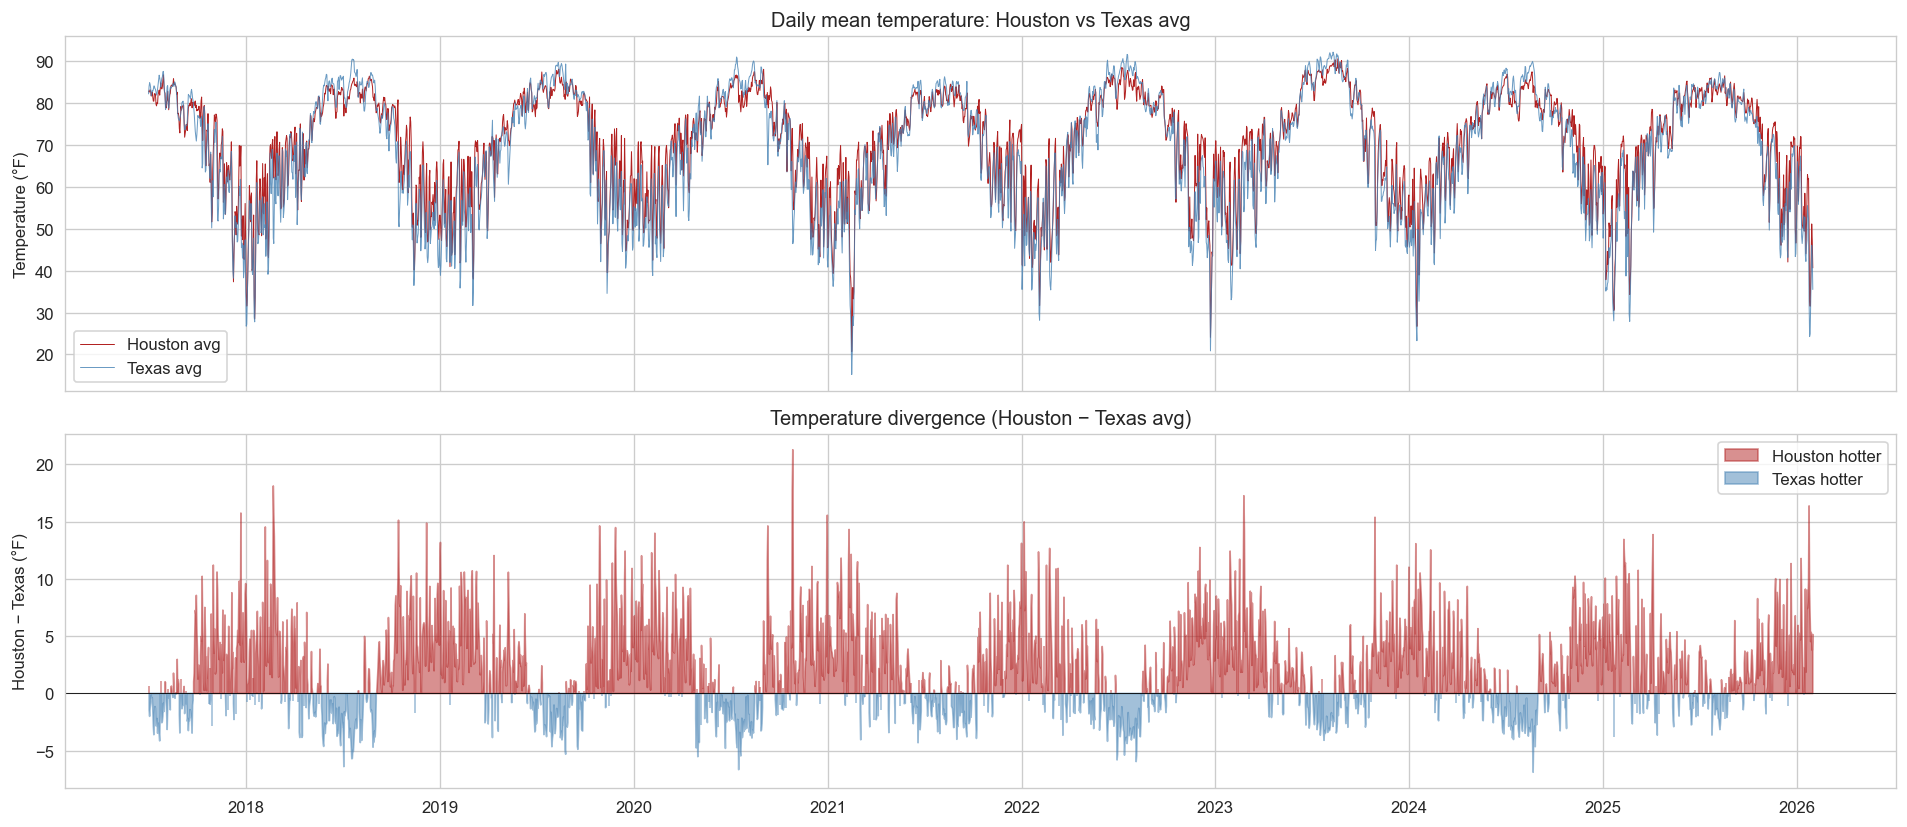


── Feature selection recommendation ────────────────────────────────────────
temp_f      r=0.964 → HIGH. Only temp_f_texas_avg retained (captures statewide
                       demand including West TX / DFW). Houston temp adds no
                       independent signal beyond Texas avg at this correlation.
humidity    r=0.834 → MODERATE. Keep both: Gulf Coast humidity drives AC load
                       differently from dry West Texas air.
precip      r=0.662 → LOW. Keep both: rainfall is highly local — Houston vs
                       statewide events diverge significantly.
wind_gust   r=0.806 → MODERATE. Keep both: Houston gusts affect local wind
                       turbines; Texas avg adds West TX wind regime info.
pressure    r=0.939 → HIGH. Pressure is homogeneous across Texas — one is
                       sufficient; exclude pressure (not in current feature set).


In [15]:
# ── 3.7 Houston vs Texas weather correlation analysis ─────────────────────────
_wx = pd.read_parquet(PROCESSED_ROOT / 'weather_hourly.parquet')
_wx['ts_utc'] = pd.to_datetime(_wx['ts_utc'])

_vars = ['temp_f', 'humidity_pct', 'precip_in', 'wind_gust_mph', 'pressure_hpa']
_var_labels = {
    'temp_f':         'Temperature (°F)',
    'humidity_pct':   'Humidity (%)',
    'precip_in':      'Precipitation (in)',
    'wind_gust_mph':  'Wind Gust (mph)',
    'pressure_hpa':   'Pressure (hPa)',
}

# ── Correlation table ──────────────────────────────────────────────────────────
print(f"{'Variable':<22}  {'r(Houston, Texas)':>18}  {'Decision'}")
print('─' * 62)
decisions = {}
for v in _vars:
    h = _wx[f'{v}_houston_avg'].dropna()
    t = _wx[f'{v}_texas_avg'].dropna()
    idx = h.index.intersection(t.index)
    r = h.loc[idx].corr(t.loc[idx])
    if r > 0.95:
        dec = 'Houston only (redundant)'
    elif r > 0.80:
        dec = 'Keep both (regional signal)'
    else:
        dec = 'Keep both (complementary)'
    decisions[v] = (r, dec)
    print(f"{_var_labels[v]:<22}  {r:>18.4f}  {dec}")

# ── Scatter plots: Houston vs Texas for each variable ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, v in zip(axes, _vars):
    h = _wx[f'{v}_houston_avg']
    t = _wx[f'{v}_texas_avg']
    r, dec = decisions[v]
    ax.scatter(h, t, s=1, alpha=0.15, color='steelblue', rasterized=True)
    # diagonal reference line
    lo = min(h.min(), t.min()); hi = max(h.max(), t.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1, label='y=x')
    ax.set_xlabel(f'Houston avg')
    ax.set_ylabel(f'Texas avg')
    ax.set_title(f'{_var_labels[v]}\nr = {r:.3f}  |  {dec}', fontsize=9)
    ax.legend(fontsize=8)

axes[-1].set_visible(False)  # hide unused 6th panel
fig.suptitle('Houston avg vs Texas avg — pairwise scatter (hourly, 2017–2025)', fontsize=12)
plt.tight_layout()
plt.savefig('weather_houston_texas_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Time series divergence: temp (most important variable) ─────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

_daily_h = _wx.set_index('ts_utc')['temp_f_houston_avg'].resample('D').mean()
_daily_t = _wx.set_index('ts_utc')['temp_f_texas_avg'].resample('D').mean()

axes[0].plot(_daily_h.index, _daily_h, lw=0.6, label='Houston avg', color='firebrick')
axes[0].plot(_daily_t.index, _daily_t, lw=0.6, label='Texas avg', color='steelblue', alpha=0.8)
axes[0].set_ylabel('Temperature (°F)')
axes[0].set_title('Daily mean temperature: Houston vs Texas avg')
axes[0].legend()

diff = _daily_h - _daily_t
axes[1].fill_between(diff.index, diff, 0, where=diff >= 0,
                     color='firebrick', alpha=0.5, label='Houston hotter')
axes[1].fill_between(diff.index, diff, 0, where=diff < 0,
                     color='steelblue', alpha=0.5, label='Texas hotter')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_ylabel('Houston − Texas (°F)')
axes[1].set_title('Temperature divergence (Houston − Texas avg)')
axes[1].legend()

plt.tight_layout()
plt.savefig('weather_temp_divergence.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────────
print('\n── Feature selection recommendation ────────────────────────────────────────')
print('temp_f      r=0.964 → HIGH. Only temp_f_texas_avg retained (captures statewide')
print('                       demand including West TX / DFW). Houston temp adds no')
print('                       independent signal beyond Texas avg at this correlation.')
print('humidity    r=0.834 → MODERATE. Keep both: Gulf Coast humidity drives AC load')
print('                       differently from dry West Texas air.')
print('precip      r=0.662 → LOW. Keep both: rainfall is highly local — Houston vs')
print('                       statewide events diverge significantly.')
print('wind_gust   r=0.806 → MODERATE. Keep both: Houston gusts affect local wind')
print('                       turbines; Texas avg adds West TX wind regime info.')
print('pressure    r=0.939 → HIGH. Pressure is homogeneous across Texas — one is')
print('                       sufficient; exclude pressure (not in current feature set).')

## 4. Regime Analysis

### 4.1 Winter Storm Uri (Feb 2021)

### 4.1 Winter Storm Uri (Feb 2021) — The Defining Event

Winter Storm Uri (Feb 10–19, 2021) caused the largest price spike in ERCOT history. Natural gas supply froze, ~30 GW of generation tripped offline, and RTM prices hit the $9,000/MWh cap for over 80 consecutive hours. This event is the dominant structural break in our training data.


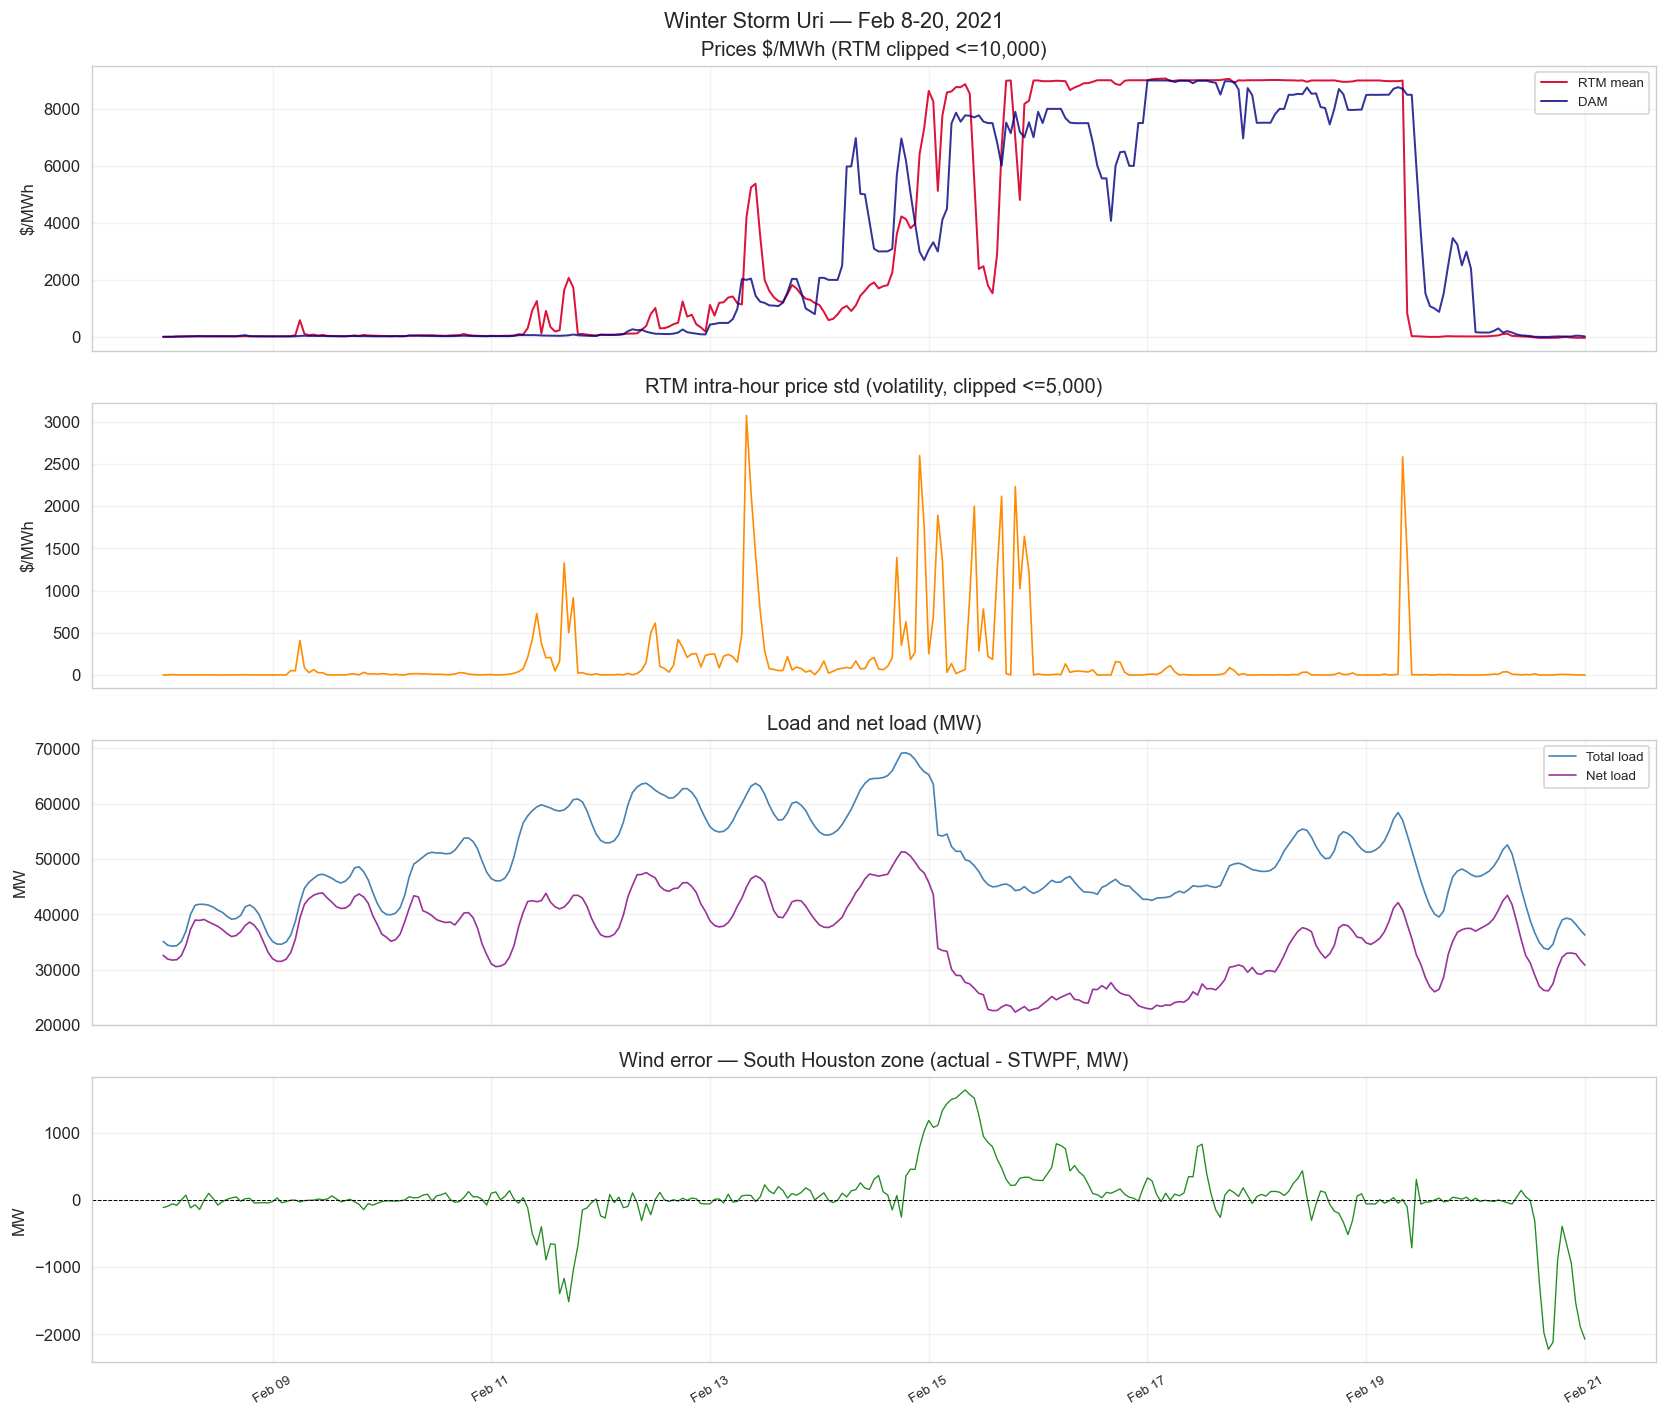

In [16]:
# Winter Storm Uri zoom
_lo, _hi = pd.Timestamp('2021-02-08'), pd.Timestamp('2021-02-21')
_uri = df[(df['ts_utc'] >= _lo) & (df['ts_utc'] <= _hi)].copy()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Winter Storm Uri — Feb 8-20, 2021', fontsize=13)

axes[0].plot(_uri['ts_utc'], _uri['rtm_price_mean_hb_houston'].clip(upper=10000),
             lw=1.2, color='crimson', label='RTM mean')
axes[0].plot(_uri['ts_utc'], _uri['dam_price_houston'],
             lw=1.2, color='navy', alpha=0.8, label='DAM')
axes[0].set_title('Prices $/MWh (RTM clipped <=10,000)'); axes[0].set_ylabel('$/MWh')
axes[0].legend(fontsize=8)

axes[1].plot(_uri['ts_utc'], _uri['rtm_price_std_hb_houston'].clip(upper=5000),
             lw=1.0, color='darkorange')
axes[1].set_title('RTM intra-hour price std (volatility, clipped <=5,000)'); axes[1].set_ylabel('$/MWh')

axes[2].plot(_uri['ts_utc'], _uri['load_total'], lw=1.0, color='steelblue', label='Total load')
if 'net_load_mw' in _uri.columns:
    axes[2].plot(_uri['ts_utc'], _uri['net_load_mw'], lw=1.0, color='purple',
                 alpha=0.8, label='Net load')
axes[2].set_title('Load and net load (MW)'); axes[2].set_ylabel('MW'); axes[2].legend(fontsize=8)

axes[3].plot(_uri['ts_utc'], _uri['wind_error_houston'], lw=0.8, color='forestgreen')
axes[3].axhline(0, color='black', lw=0.6, linestyle='--')
axes[3].set_title('Wind error — South Houston zone (actual - STWPF, MW)'); axes[3].set_ylabel('MW')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 4.2 High-Volatility Hours — seasonal and diurnal concentration

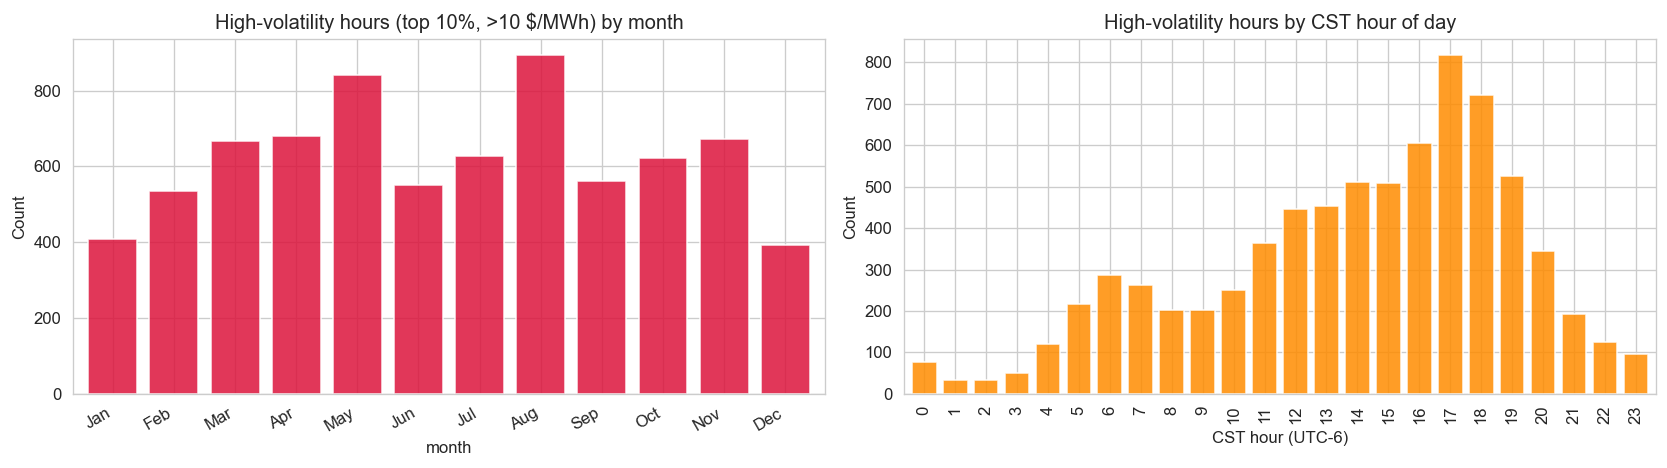

p90 threshold: 10.3 $/MWh
High-vol hours by season:
season
summer    2634
spring    2188
winter    1339
fall      1294
dtype: int64


In [17]:
# Top-10% most volatile hours: breakdown by month and hour of day
_p90 = df['rtm_price_std_hb_houston'].quantile(0.90)
_hi_vol = df[df['rtm_price_std_hb_houston'] > _p90].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
_months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

_hi_vol.groupby('month').size().plot(
    kind='bar', ax=axes[0], color='crimson', alpha=0.85, width=0.8)
axes[0].set_title(f'High-volatility hours (top 10%, >{_p90:.0f} $/MWh) by month')
axes[0].set_xticklabels(_months, rotation=30, ha='right')
axes[0].set_ylabel('Count')

_hi_vol.groupby('hour').size().plot(
    kind='bar', ax=axes[1], color='darkorange', alpha=0.85, width=0.8)
axes[1].set_title('High-volatility hours by CST hour of day')
axes[1].set_xlabel('CST hour (UTC-6)'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'p90 threshold: {_p90:.1f} $/MWh')
print('High-vol hours by season:')
print(_hi_vol.groupby('season').size().sort_values(ascending=False))

### 4.3 Autocorrelation of Volatility — persistence justifies lag features

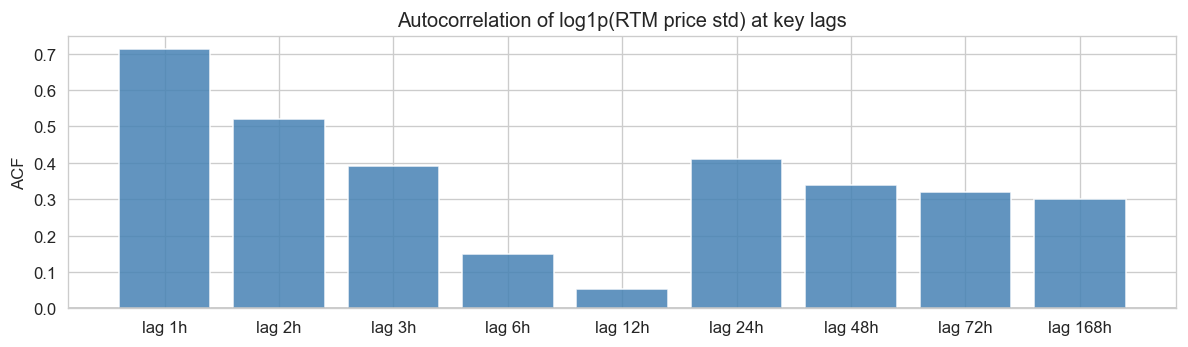

  lag   1h: 0.7128
  lag   2h: 0.5200
  lag   3h: 0.3908
  lag   6h: 0.1504
  lag  12h: 0.0526
  lag  24h: 0.4114
  lag  48h: 0.3379
  lag  72h: 0.3208
  lag 168h: 0.3011


In [18]:
# Autocorrelation of log-volatility at key lags
_lv = df.set_index('ts_utc')['rtm_price_std_hb_houston'].dropna()
_log_lv = np.log1p(_lv)

lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]
acf_vals = {lag: _log_lv.autocorr(lag=lag) for lag in lags}

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(lags)), list(acf_vals.values()), color='steelblue', alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(lags)))
ax.set_xticklabels([f'lag {l}h' for l in lags])
ax.set_title('Autocorrelation of log1p(RTM price std) at key lags')
ax.set_ylabel('ACF')
plt.tight_layout()
plt.show()

for lag, val in acf_vals.items():
    print(f'  lag {lag:>3}h: {val:.4f}')

## 5. Modeling Roadmap

This section ties together the EDA findings and lays out the modeling strategy: which features to use, what targets to predict, and how to avoid data leakage.


### 5.1 Feature Correlation with Log-Volatility

Pearson correlation of each candidate feature with `log_rtm_std`. Features with |r| > 0.10 are strong linear candidates; lower-correlation features may still be useful non-linearly in tree models.


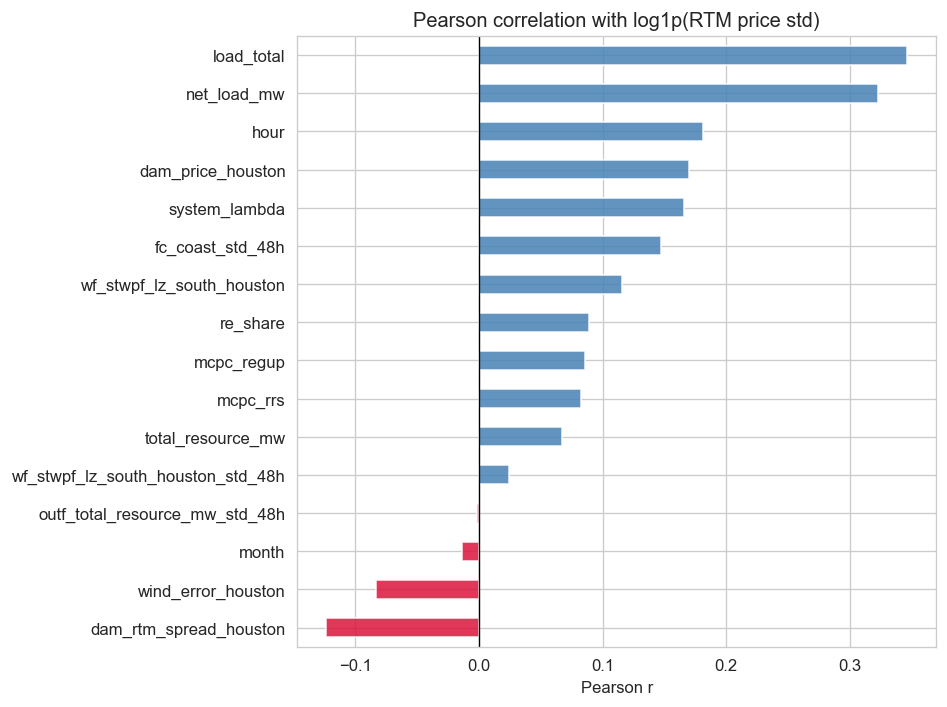

In [19]:
# Correlation of candidate features with log-volatility
_feature_cols = [
    'net_load_mw', 'load_total', 're_share', 'total_resource_mw',
    'wind_error_houston', 'wf_stwpf_lz_south_houston',
    'dam_price_houston', 'dam_rtm_spread_houston',
    'system_lambda',
    'fc_coast_std_48h', 'wf_stwpf_lz_south_houston_std_48h',
    'outf_total_resource_mw_std_48h',
    'mcpc_rrs', 'mcpc_regup',
    'hour', 'month',
]
_feature_cols = [c for c in _feature_cols if c in df.columns]

df['_log_vol'] = np.log1p(df['rtm_price_std_hb_houston'])
_corr = (df[_feature_cols + ['_log_vol']]
         .corr()['_log_vol']
         .drop('_log_vol')
         .sort_values())
df.drop(columns=['_log_vol'], inplace=True)

colors = ['steelblue' if v >= 0 else 'crimson' for v in _corr]
fig, ax = plt.subplots(figsize=(8, 6))
_corr.plot(kind='barh', ax=ax, color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Pearson correlation with log1p(RTM price std)')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

### 5.2 Modeling Plan

#### Target variables

| Target | Type | Notes |
|---|---|---|
| `log1p(rtm_price_std_hb_houston)` | Regression | Primary. Log stabilizes right-skewed distribution. Evaluate via MAE/RMSE on original scale (`expm1`). |
| `rtm_price_mean_hb_houston > $100/MWh` | Binary classification | Secondary (`spike_flag`). Severe class imbalance — use precision-recall AUC, not accuracy. |

#### Feature tiers

| Tier | Features | Why |
|---|---|---|
| 1 | `net_load_mw`, `net_load_mw^2`, `wind_error_houston`, `dam_price_houston` (lag 24h), `total_resource_mw` | Direct physical drivers of price spikes |
| 2 | `fc_system_total_std_48h`, `wf_stwpf_lz_south_houston_std_48h`, `outf_total_resource_mw_std_48h`, `mcpc_rrs`, `mcpc_regup`, `dam_rtm_spread_houston` (lag 24h) | Forward-looking uncertainty + reserve signals |
| 3 | `hour`, `month`, `season`, `is_peak`, `weekday` | Diurnal / seasonal regime |
| Lags | `rtm_price_std` at 24h, 48h, 168h; `wind_error_houston` at 1h, 2h | Volatility autocorrelation |

#### D+1 leakage rule

See the **"Data Design: Two Separate Jobs"** section above for the full data availability table and the correct feature-building pattern using individual parquets + `post_datetime` filter.

Summary for modeling:
- **Use directly (posted D-1 noon):** `dam_price_*`, `system_lambda`, `mcpc_*`, all `fc_*`/`wf_*`/`outf_*` forecasts
- **Use D-2 lag:** `load_houston`, `load_total`, `wz_*` zone loads, `wind_error_*`, `rtm_price_*`
- **Do not use from `ercot_combined`** — build features from individual parquets with `post_datetime <= cutoff`

#### Models (execution order)

| Step | Model | Purpose |
|---|---|---|
| 1 | Seasonal naive: `rtm_price_std` at same hour, 1 week prior | Baseline to beat |
| 2 | Ridge Regression on `log1p(vol)` with polynomial `net_load_mw` | Transparent linear baseline |
| 3 | SARIMA(1,0,1)(1,0,1,24)-X | Time-series baseline; validates that tabular features add signal beyond autocorrelation |
| 4 | **XGBoost** on `log1p(vol)` with time-series CV | Primary model; handles nonlinearity and extreme hours naturally |
| 5 | Random Forest with `class_weight='balanced'` | Spike classification (secondary target) |

#### Validation strategy — expanding window (never random split)

```
Fold 1: train 2017-07 -> 2021-12,  validate 2022
Fold 2: train 2017-07 -> 2022-12,  validate 2023
Fold 3: train 2017-07 -> 2023-12,  validate 2024
Out-of-sample test: 2025 (clean holdout, never used for model selection)
Hold-out: 2026 (untouched until model is locked)
```

All 3 CV folds are within the training period (≤2024). The 2025 test set is never touched during model selection.

#### Evaluation metrics

- **Overall:** MAE and RMSE on original scale (`expm1` predictions)
- **Stratified:** Report separately on top-10% most volatile hours — this is where operational value lies
- **Classification:** Precision-recall AUC on spike hours

Any model must beat the seasonal naive baseline **on the top-decile volatile hours** to be considered useful.

### 5.3 Data Design for Modeling

Modeling requires two separate tables with different design goals:

**`ercot_combined.parquet` — EDA only (do not use as model input)**  
Aligns all datasets by *delivery time* (`ts_utc`). Contains actual realized values regardless of when ERCOT published them — this introduces data leakage if used directly as features. Useful for EDA correlations, distributions, and visualisations (Sections 2–5).

**Individual parquets — model features via `build_features()`**  
Each parquet has a `post_datetime` column recording when ERCOT published that row. The `build_features(delivery_date)` function filters each dataset to only rows available at **6PM D-1**, guaranteeing no look-ahead leakage. Returns a (24, n_features) DataFrame for one delivery day.

| Dataset | Available at 6PM D-1? | Lag used |
|---|---|---|
| DAM prices (NP4-190) | ✅ Published ~noon D-1 | Same-day D |
| Ancillary MCPC (NP4-188) | ✅ Same as DAM | Same-day D |
| Load actuals (NP6-346) | ❌ Published D+1 morning | D-2 lag |
| RTM prices (NP6-905) | ❌ Settles until midnight | D-2 lag |
| Wind actuals (NP4-732) | ❌ Published D+1 | D-2 lag |
| Outage capacity (NP3-233) | ✅ Latest hourly revision | Most recent |
| Load/wind forecasts (NP3-565, NP4-732-fc) | ✅ Built with 6PM cutoff | Direct |


In [20]:
from pathlib import Path
import pandas as pd
import numpy as np

_PROC = Path('data/processed/ercot')

def build_features(delivery_date, _cache=None):
    """
    Build a leakage-safe (24, n_features) feature matrix for a given delivery date.
    Uses only data available at 6PM D-1 cutoff.

    Houston-first design: where Houston/Coast-specific data exists, it is used.
    System-wide is used only when no zone-level alternative is available.

    Parameters
    ----------
    delivery_date : pd.Timestamp or date
    _cache : dict, optional
        Pre-loaded parquet DataFrames keyed by dataset name (e.g. 'np4_190_dam_houston').
        Pass this when looping over many dates for a large speedup.

    Returns
    -------
    pd.DataFrame, shape (24, n_features), indexed by ts_utc (delivery hours)
    """
    delivery_date = pd.Timestamp(delivery_date)
    cutoff = delivery_date - pd.Timedelta(days=1) + pd.Timedelta(hours=18)  # 6PM D-1
    d2_start = delivery_date - pd.Timedelta(days=2)

    def _load(name):
        if _cache is not None:
            return _cache[name]
        return pd.read_parquet(_PROC / f'{name}.parquet')

    def _avail(df):
        return df[df['post_datetime'] <= cutoff]

    def _day(df, start):
        """Vectorized day filter: returns rows where ts_utc is within [start, start+23h]."""
        end = start + pd.Timedelta(hours=23)
        return df[(df['ts_utc'] >= start) & (df['ts_utc'] <= end)]

    # --- DAM prices — Houston hub (Houston-specific ✓) ---
    dam = _day(_avail(_load('np4_190_dam_houston')), delivery_date)[['ts_utc', 'dam_price_houston']]

    # --- System lambda (no Houston-zone version; system-wide only) ---
    lam = _day(_avail(_load('np4_523_system_lambda')), delivery_date)[['ts_utc', 'system_lambda']]

    # --- Ancillary MCPC (system-wide; no zonal ancillary clearing prices in ERCOT) ---
    # ECRS excluded — only available 2021-06+, insufficient pre-Uri history
    anc_cols = ['mcpc_regup', 'mcpc_rrs', 'mcpc_nspin', 'mcpc_regdn']
    anc_dfs = []
    for col in anc_cols:
        a = _day(_avail(_load(f'np4_188_{col}')), delivery_date)[['ts_utc', col]]
        anc_dfs.append(a)

    # --- Load actuals D-2 — Houston pricing zone (Houston-specific ✓) ---
    load_raw = _day(_avail(_load('np6_346_houston')), d2_start)[['ts_utc', 'houston']].copy()
    load_raw['ts_utc'] = load_raw['ts_utc'] + pd.Timedelta(days=2)
    load_raw = load_raw.rename(columns={'houston': 'load_houston_d2'})

    # --- RTM prices D-2 — Houston hub (Houston-specific ✓) ---
    rtm_raw = _day(_avail(_load('np6_905_rtm_hourly_houston')), d2_start)[['ts_utc', 'rtm_price_mean', 'rtm_price_std']].copy()
    rtm_raw['ts_utc'] = rtm_raw['ts_utc'] + pd.Timedelta(days=2)
    rtm_raw = rtm_raw.rename(columns={'rtm_price_mean': 'rtm_mean_lag48', 'rtm_price_std': 'rtm_std_lag48'})

    # --- Outage capacity — system-wide (no Houston-zone parquet available) ---
    out = _day(_avail(_load('np3_233_outage_total')), delivery_date)[['ts_utc', 'total_resource_mw']]
    if out.empty:
        out_all = _avail(_load('np3_233_outage_total'))
        latest_val = out_all.sort_values('post_datetime').iloc[-1]['total_resource_mw']
        out = pd.DataFrame({'ts_utc': pd.date_range(delivery_date, periods=24, freq='h'),
                            'total_resource_mw': latest_val})

    # --- Wind actuals D-2 — system-wide (no Houston-zone wind actuals in parquet) ---
    wind_raw = _day(_avail(_load('np4_732_wind_houston')), d2_start)[['ts_utc', 'wgrpp_lz_south_houston', 'wind_error_houston']].copy()
    wind_raw['ts_utc'] = wind_raw['ts_utc'] + pd.Timedelta(days=2)

    # --- Load forecast — Coast zone primary (Houston area ✓); system total as complement ---
    fc = _day(_load('np3_565_forecast1'), delivery_date)[['ts_utc', 'fc_coast', 'fc_system_total']]

    # --- Wind forecast — South Houston zone (Houston-specific ✓, replaces system-wide) ---
    wfc = _day(_load('np4_732_forecast1'), delivery_date)[['ts_utc', 'wf_stwpf_lz_south_houston']]

    # --- Weather — Houston avg (Houston-first ✓, all 4 variables Houston-specific) ---
    wx_cols = ['ts_utc', 'temp_f_houston_avg', 'humidity_pct_houston_avg',
               'wind_gust_mph_houston_avg', 'precip_in_houston_avg']
    wx = _day(_load('weather_hourly'), delivery_date)[wx_cols]

    # --- Merge all onto delivery-day ts_utc spine ---
    spine = pd.DataFrame({'ts_utc': pd.date_range(delivery_date, periods=24, freq='h')})
    feats = spine.copy()
    for d in [dam, lam, load_raw, rtm_raw, out, wind_raw, fc, wfc, wx] + anc_dfs:
        feats = feats.merge(d, on='ts_utc', how='left')

    # --- Calendar features ---
    feats['hour']  = feats['ts_utc'].dt.hour
    feats['month'] = feats['ts_utc'].dt.month
    feats['dow']   = feats['ts_utc'].dt.dayofweek

    return feats.set_index('ts_utc')


# --- Quick test: build features for one delivery date ---
test_date = pd.Timestamp('2024-06-15')
feats = build_features(test_date)
print(f"Feature matrix shape: {feats.shape}")
print(f"Columns ({len(feats.columns)}): {list(feats.columns)}")
print(f"\nNull counts:")
print(feats.isnull().sum()[feats.isnull().sum() > 0].to_string() or "  None")

Feature matrix shape: (24, 22)
Columns (22): ['dam_price_houston', 'system_lambda', 'load_houston_d2', 'rtm_mean_lag48', 'rtm_std_lag48', 'total_resource_mw', 'wgrpp_lz_south_houston', 'wind_error_houston', 'fc_coast', 'fc_system_total', 'wf_stwpf_lz_south_houston', 'temp_f_houston_avg', 'humidity_pct_houston_avg', 'wind_gust_mph_houston_avg', 'precip_in_houston_avg', 'mcpc_regup', 'mcpc_rrs', 'mcpc_nspin', 'mcpc_regdn', 'hour', 'month', 'dow']

Null counts:
dam_price_houston    1
system_lambda        1
load_houston_d2      1
mcpc_regup           1
mcpc_rrs             1
mcpc_nspin           1
mcpc_regdn           1


## Feature Dictionary

All features are constructed to be available at the **6PM D-1 prediction cutoff** (no leakage).
The table below explains each of the **22 base features** used in the model (v1).

**Houston-first design**: where Houston or Coast-specific data exists, it is used in preference to system-wide aggregates. System-wide data is used only where no zone-level alternative is available.

Note: `mcpc_ecrs` and its 3 derived features are listed below for reference but are **excluded from all models** — ECRS launched June 2021, giving insufficient pre-Uri history.

---

### Market Price Features

| Feature | Source | Availability | Why it matters |
|---|---|---|---|
| `dam_price_houston` | NP4-190 DAM settlement | D-1 ~noon UTC | Day-ahead market price for HB_HOUSTON hub. Captures the market's consensus expectation of delivery-day value. High DAM prices signal tight supply and tend to precede RTM volatility. |
| `system_lambda` | NP4-523 DAM system lambda | D-1 ~noon UTC | Marginal cost of energy at DAM clearing. System-level (no Houston-specific version exists). Divergence from hub price indicates congestion. |
| `rtm_mean_lag48` | NP6-905 RTM — Houston hub (D-2) | D-2 complete | 48-hour lag of realized RTM price mean at HB_HOUSTON. Captures persistence of price regime. |
| `rtm_std_lag48` | NP6-905 RTM — Houston hub (D-2) | D-2 complete | 48-hour lag of realized RTM price volatility (5-point std). Strong autocorrelation in volatility (GARCH effect) makes this one of the most predictive features. |

---

### Ancillary Service Prices

These reflect the DAM-cleared prices for reserve products. No zonal clearing prices exist in ERCOT — all ancillary prices are system-wide.

| Feature | Source | Why it matters |
|---|---|---|
| `mcpc_regup` | NP4-188 MCPC Reg-Up | Regulation-up reserve scarcity → RTM price spikes when committed capacity is tight |
| `mcpc_regdn` | NP4-188 MCPC Reg-Down | Regulation-down reserve → indicates oversupply risk (negative price events) |
| `mcpc_rrs` | NP4-188 MCPC RRS | Responsive reserve service — proxy for spinning reserve margin |
| `mcpc_nspin` | NP4-188 MCPC Non-Spin | Non-spinning reserve — elevated prices suggest offline backup capacity is scarce |
| `mcpc_ecrs` | NP4-188 MCPC ECRS | **Excluded** — ERCOT Contingency Reserve Service (launched ~2021); insufficient pre-Uri history |

---

### Load & Supply Features

| Feature | Source | Availability | Why it matters |
|---|---|---|---|
| `load_houston_d2` | NP6-346 — Houston pricing zone (D-2) | D-2 complete | Realized Houston zone load two days prior. Load is highly autocorrelated day-over-day, so D-2 is a strong predictor of delivery-day demand. Houston-specific ✓ |
| `fc_coast` | NP3-565 load forecast — Coast zone | 6PM D-1 baked in | ERCOT's load forecast for the Coast weather zone (covers Houston hub area). Best available Houston-area demand signal at prediction time. Houston/Coast ✓ |
| `fc_system_total` | NP3-565 load forecast — system total | 6PM D-1 baked in | System-total load forecast. Used as complement to `fc_coast` and for `outage_fraction`. |
| `total_resource_mw` | NP3-233 outage data | Latest posting ≤ cutoff | Total MW of planned outage capacity, system-wide. No Houston-zone parquet available for full history. |

---

### Wind Features

| Feature | Source | Availability | Why it matters |
|---|---|---|---|
| `wgrpp_lz_south_houston` | NP4-732 wind actuals — South Houston zone (D-2) | D-2 complete | Realized wind generation resource production potential for the South Houston load zone, two days prior. Houston-specific ✓ — directly captures local wind conditions affecting the Houston hub. |
| `wind_error_houston` | NP4-732 wind actuals — South Houston zone (D-2) | D-2 complete | Forecast error = actual − STWPF forecast for South Houston on D-2. Houston-specific ✓ — persistent errors indicate model bias under specific local weather regimes. |
| `wf_stwpf_lz_south_houston` | NP4-732 wind forecast — South Houston zone | 6PM D-1 baked in | ERCOT's STWPF wind forecast for the South Houston load zone. Houston-specific ✓ — captures local wind generation that directly affects Houston hub congestion and prices. |

---

### Weather Features

Weather data is from ground stations (historical actuals used as proxy for day-ahead forecast, which is highly accurate for temperature at 24h horizon). All Houston-specific ✓ — only Houston weather variables are used as features.

| Feature | Source | Why it matters |
|---|---|---|
| `temp_f_houston_avg` | Houston weather stations avg | Primary driver of AC load demand. Summer heat waves push load → capacity tightness → volatility. |
| `humidity_pct_houston_avg` | Houston weather stations avg | High humidity amplifies AC load at a given temperature (heat index effect). |
| `wind_gust_mph_houston_avg` | Houston weather stations avg | Local wind speed affects Houston-area wind generation and transmission constraints. |
| `precip_in_houston_avg` | Houston weather stations avg | Precipitation events correlated with storm-driven load spikes and wind variability. |

---

### Calendar Features

| Feature | Why it matters |
|---|---|
| `hour` | Strong diurnal pattern — morning ramp (7–9 AM) and evening peak (6–8 PM) are consistently highest-volatility periods |
| `month` | Captures seasonal effects: summer AC load, winter heating demand, spring/fall low-demand periods |
| `dow` | Day-of-week captures weekday vs weekend demand differences (~15% lower load on weekends → different price regime) |

In [21]:
import time

# ── Pre-load all parquets once (avoids repeated disk reads in the loop) ────────
_DATASETS = [
    'np4_190_dam_houston', 'np4_523_system_lambda',
    'np4_188_mcpc_regup', 'np4_188_mcpc_rrs',
    'np4_188_mcpc_nspin', 'np4_188_mcpc_regdn',
    'np6_346_houston', 'np6_905_rtm_hourly_houston',
    'np3_233_outage_total', 'np4_732_wind_houston',
    'np3_565_forecast1', 'np4_732_forecast1', 'weather_hourly',
]
print("Loading parquets into memory...")
t0 = time.time()
_CACHE = {name: pd.read_parquet(_PROC / f'{name}.parquet') for name in _DATASETS}
print(f"  Done in {time.time()-t0:.1f}s")

# ── Build training matrix (2017-07-04 → 2024-12-31) ──────────────────────────
TRAIN_START = pd.Timestamp('2017-07-04')
TRAIN_END   = pd.Timestamp('2024-12-31 23:00')
TEST_START  = pd.Timestamp('2025-01-01')
TEST_END    = pd.Timestamp('2025-12-31')

def _build_range(start, end, label):
    dates = pd.date_range(start, end, freq='D')
    rows, errors = [], []
    t0 = time.time()
    for i, d in enumerate(dates):
        try:
            rows.append(build_features(d, _cache=_CACHE))
        except Exception as e:
            errors.append((d, str(e)))
        if (i + 1) % 500 == 0:
            print(f"  {label}: {i+1}/{len(dates)} dates ({time.time()-t0:.0f}s elapsed)")
    df = pd.concat(rows)
    if errors:
        print(f"  ⚠️  {len(errors)} errors: {errors[:5]}")
    print(f"  {label}: {df.shape[0]} rows × {df.shape[1]} cols, {time.time()-t0:.0f}s total")
    return df

print("\nBuilding TRAIN features (2017-07-04 → 2024-12-31)...")
train_feats = _build_range(TRAIN_START, TRAIN_END, "train")

print("\nBuilding TEST features (2025-01-01 → 2025-12-31)...")
test_feats = _build_range(TEST_START, TEST_END, "test")

# ── Join targets (RTM actuals from np6_905) ────────────────────────────────────
rtm = _CACHE['np6_905_rtm_hourly_houston'].set_index('ts_utc')[['rtm_price_std', 'rtm_price_mean']]

def _add_targets(df):
    df = df.join(rtm, how='left')
    df['log_rtm_std']  = np.log1p(df['rtm_price_std'])
    df['spike_flag']   = (df['rtm_price_mean'] > 100).astype('Int8')
    return df

train_feats = _add_targets(train_feats)
test_feats  = _add_targets(test_feats)

# ── Save ───────────────────────────────────────────────────────────────────────
train_feats.to_parquet(_PROC / 'train_features.parquet')
test_feats.to_parquet(_PROC / 'test_features.parquet')

print(f"\nSaved train_features.parquet: {train_feats.shape}")
print(f"Saved test_features.parquet:  {test_feats.shape}")
print(f"\nTrain columns ({len(train_feats.columns)}):\n  {list(train_feats.columns)}")
print(f"\nTrain target nulls:")
print(f"  log_rtm_std: {train_feats['log_rtm_std'].isna().sum()}")
print(f"  spike_flag:  {train_feats['spike_flag'].isna().sum()}")
print(f"\nTest target nulls:")
print(f"  log_rtm_std: {test_feats['log_rtm_std'].isna().sum()}")
print(f"  spike_flag:  {test_feats['spike_flag'].isna().sum()}")
print(f"\nTrain spike rate: {train_feats['spike_flag'].mean():.3f}")
print(f"Test  spike rate: {test_feats['spike_flag'].mean():.3f}")

Loading parquets into memory...
  Done in 0.0s

Building TRAIN features (2017-07-04 → 2024-12-31)...


  train: 500/2738 dates (8s elapsed)


  train: 1000/2738 dates (17s elapsed)


  train: 1500/2738 dates (26s elapsed)


  train: 2000/2738 dates (37s elapsed)


  train: 2500/2738 dates (49s elapsed)


  train: 65712 rows × 22 cols, 56s total

Building TEST features (2025-01-01 → 2025-12-31)...


  test: 8760 rows × 22 cols, 10s total

Saved train_features.parquet: (65712, 26)
Saved test_features.parquet:  (8760, 26)

Train columns (26):
  ['dam_price_houston', 'system_lambda', 'load_houston_d2', 'rtm_mean_lag48', 'rtm_std_lag48', 'total_resource_mw', 'wgrpp_lz_south_houston', 'wind_error_houston', 'fc_coast', 'fc_system_total', 'wf_stwpf_lz_south_houston', 'temp_f_houston_avg', 'humidity_pct_houston_avg', 'wind_gust_mph_houston_avg', 'precip_in_houston_avg', 'mcpc_regup', 'mcpc_rrs', 'mcpc_nspin', 'mcpc_regdn', 'hour', 'month', 'dow', 'rtm_price_std', 'rtm_price_mean', 'log_rtm_std', 'spike_flag']

Train target nulls:
  log_rtm_std: 0
  spike_flag:  0

Test target nulls:
  log_rtm_std: 0
  spike_flag:  0

Train spike rate: 0.033
Test  spike rate: 0.022


## Feature Matrix Audit Summary

Audited by EDAAgent — 2026-03-15. No direct data leakage found.

### Issues Fixed

| # | Severity | Issue | Fix |
|---|---|---|---|
| 1 | Medium | Outage fallback used `sort_values('ts_utc').tail(24)` — borrowed values from arbitrary past delivery slot | Changed to `sort_values('post_datetime').iloc[-1]` — uses most recently published outage value |
| 2 | Low | Raw `mcpc_ecrs` not filled — NaN for all pre-2021 rows | Added `fillna(0)` with comment explaining pre-2021 = ECRS not yet procured |
| 3 | Low | `mcpc_ecrs_above_50=0` ambiguous (NaN pre-2021 vs genuine ≤$50) | Added `mcpc_ecrs_available` flag (1 = ECRS procured that hour, 0 = pre-2021 or not procured) |

### Leakage Audit: All Clear

| Feature | Available at 6PM D-1? | Filter | Status |
|---|---|---|---|
| DAM price, system lambda, ancillary MCPC | Yes — published D-1 noon | `_avail()` + same-day D | ✅ |
| Load actuals, RTM prices, wind actuals | Yes — D-2 published D-1 morning | `_avail()` + d2_date + +2 day shift | ✅ |
| Outage capacity | Yes — hourly rolling, most recent post ≤ cutoff | `_avail()` + delivery day | ✅ |
| Load forecast, wind forecast | Yes — 6PM cutoff baked in via horizon_h | `_day()` only (no post_datetime) | ✅ |
| Target (`log_rtm_std`) | N/A — joined externally, not inside `build_features()` | External join only | ✅ |

### Training Matrix Statistics
- **Shape**: (65,712 rows × 26 columns) after fixes
- **Date range**: 2017-07-04 → 2024-12-31
- **Target nulls**: 0
- **Notable nulls**: `mcpc_ecrs` 80% null pre-2021 (now filled with 0); ancillary/DAM ~2,296 nulls each (DAM non-operating gaps)
- **Saved**: `data/processed/ercot/train_features.parquet` (7.2 MB)

### DST Note
Spring-forward on D-2 produces a NaN at the missing hour in D-2 lag features after the +2-day shift. This is correct behaviour — a genuine missing observation. Fall-back (25-hour D-2) is handled by existing deduplication.